In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint
import json
import os

# Analisi Esperimenti — Confronto Strategie di Prompting

| Config | Optimizer | Target | File |
|--------|-----------|--------|------|
| A | llama3.1:8b | mistral-nemo | `llama3.1-Nemo.json` |
| B | mistral-nemo | llama3.1:8b | `Nemo-llama3.1.json` |
| C | mistral-nemo | mistral-nemo | `Nemo-Nemo.json` |

In [3]:

# Risale alla root del progetto indipendentemente da dove viene eseguito il notebook
CWD = os.path.abspath(os.getcwd())
BASE = os.path.dirname(CWD) if os.path.basename(CWD) == 'notebooks' else CWD

CONFIGS = [
    {
        'label':     'Config A — llama3.1 → Nemo',
        'optimizer': 'llama3.1:8b',
        'target':    'mistral-nemo',
        'file':      os.path.join(BASE, 'result', 'llama3.1-Nemo.json'),
        'partial':   False,
    },
    {
        'label':     'Config B — Nemo → llama3.1',
        'optimizer': 'mistral-nemo',
        'target':    'llama3.1:8b',
        'file':      os.path.join(BASE, 'result', 'Nemo-llama3.1.json'),
        'partial':   False,
    },
    {
        'label':     'Config C — Nemo → Nemo',
        'optimizer': 'mistral-nemo',
        'target':    'mistral-nemo',
        'file':      os.path.join(BASE, 'result', 'Nemo-Nemo.json'),
        'partial':   False,
    },
    {
        'label':     'Config D — gemma2 → phi3',
        'optimizer': 'gemma2:9b',
        'target':    'phi3:medium',
        'file':      os.path.join(BASE, 'result', 'gemma2-phi3.json'),
        'partial':   True,
    },
]

PASS_K_VALUES = [1, 3, 5, 10]

def load_config(cfg):
    with open(cfg['file'], encoding='utf-8') as f:
        raw = json.load(f)

    def get_passk(entry, method, k):
        return entry[method].get('pass_at_k', {}).get(f'pass@{k}', np.nan)

    rows = []
    for x in raw:
        row = {
            'idx':                x['problem_idx'],
            'difficulty':         x['difficulty'],
            'n_test_cases':       x['n_test_cases'],
            'original_problem':   x['question'],
            'accuracy_zero_shot': x['zero_shot']['accuracy'],
            'baseline':           x['baseline']['accuracy'],
            'APE':                x['APE']['best_accuracy'],
            'APO':                x['APO']['best_accuracy'],
        }
        for k in PASS_K_VALUES:
            row[f'APE_pass@{k}'] = get_passk(x, 'APE', k)
            row[f'APO_pass@{k}'] = get_passk(x, 'APO', k)
        rows.append(row)

    return pd.DataFrame(rows)

dfs = {}
for cfg in CONFIGS:
    label = cfg['label']
    dfs[label] = load_config(cfg)
    n = len(dfs[label])
    

df_A = dfs['Config A — llama3.1 → Nemo']
df_B = dfs['Config B — Nemo → llama3.1']
df_C = dfs['Config C — Nemo → Nemo']
df_D = dfs['Config D — gemma2 → phi3']

dfs[CONFIGS[0]['label']].head()


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\dernj\\Desktop\\Tesi_esperimenti\\result\\llama3.1-Nemo.json'

In [15]:
METHODS = ['accuracy_zero_shot', 'baseline', 'APE', 'APO']
LABELS  = ['Zero-Shot', 'Baseline', 'APE', 'APO']
COLORS  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

def generate_graph(df, title, save_path=None):
    df_nz = df[df[METHODS].max(axis=1) > 0].copy()

    fig, axes = plt.subplots(3, 2, figsize=(14, 16))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    # --- 1. Mean accuracy bar chart ---
    ax = axes[0, 0]
    means = [df[m].mean() for m in METHODS]
    bars = ax.bar(LABELS, means, color=COLORS, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title('Mean Accuracy per Method (all problems)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, max(means) * 1.4 + 0.02)

    # --- 2. Boxplot (nonzero problems) ---
    ax = axes[0, 1]
    ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,
               boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Accuracy Distribution (nonzero problems, n={len(df_nz)})')
    ax.set_ylabel('Accuracy')

    # --- 3. Per-problem accuracy (nonzero) ---
    ax = axes[1, 0]
    for m, lbl, c in zip(METHODS, LABELS, COLORS):
        ax.plot(df_nz['idx'], df_nz[m], label=lbl, color=c, marker='o', markersize=4, linewidth=1.4)
    ax.set_title('Per-Problem Accuracy (nonzero problems only)')
    ax.set_xlabel('Problem idx')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)

    # --- 4. Improvement over Zero-Shot ---
    ax = axes[1, 1]
    for m, lbl, c in zip(METHODS[1:], LABELS[1:], COLORS[1:]):
        ax.plot(df_nz['idx'], df_nz[m] - df_nz['accuracy_zero_shot'],
                label=f'{lbl} - Zero-Shot', color=c, marker='o', markersize=4, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Improvement over Zero-Shot (nonzero problems only)')
    ax.set_xlabel('Problem idx')
    ax.set_ylabel('Δ Accuracy')
    ax.legend(fontsize=8)

    # --- 5. Heatmap ---
    ax = axes[2, 0]
    heat_data = df_nz[METHODS].set_index(df_nz['idx']).T
    heat_data.index = LABELS
    im = ax.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(df_nz)))
    ax.set_xticklabels(df_nz['idx'], fontsize=8, rotation=90)
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_title('Accuracy Heatmap (nonzero problems only)')
    plt.colorbar(im, ax=ax, fraction=0.03)

    # --- 6. Win count (strict) ---
    ax = axes[2, 1]
    win_counts = {lbl: 0 for lbl in LABELS}
    for _, row in df[METHODS].iterrows():
        best = row.max()
        winners = [lbl for lbl, m in zip(LABELS, METHODS) if row[m] == best]
        if len(winners) == 1:
            win_counts[winners[0]] += 1
    bars = ax.bar(win_counts.keys(), win_counts.values(), color=COLORS, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title('Strict Win Count per Method\n(ties excluded)')
    ax.set_ylabel('# Problems')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f'Saved: {save_path}')
    plt.show()

---
## Config A — llama3.1:8b (Optimizer) → mistral-nemo (Target)

In [20]:
df_A = dfs['Config A — llama3.1 → Nemo']
print(df_A[METHODS].describe().round(3))
df_A.head(10)

       accuracy_zero_shot  baseline     APE     APO
count              30.000    30.000  30.000  30.000
mean                0.042     0.028   0.135   0.193
std                 0.142     0.078   0.271   0.324
min                 0.000     0.000   0.000   0.000
25%                 0.000     0.000   0.000   0.000
50%                 0.000     0.000   0.000   0.000
75%                 0.000     0.000   0.039   0.303
max                 0.684     0.368   1.000   1.000


,idx,difficulty,n_test_cases,original_problem,accuracy_zero_shot,baseline,APE,APO,APE_pass@1,APO_pass@1,APE_pass@3,APO_pass@3,APE_pass@5,APO_pass@5,APE_pass@10,APO_pass@10
0,0,introductory,1,You are given an array $a$ of length $n$ consi...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,0.0000,0.0000
1,1,introductory,1,$n$ robots have escaped from your laboratory! ...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,0.0000,0.0000
2,2,introductory,1,There are $n$ athletes in front of you. Athlet...,0.0,0.0,0.0,1.0,0.0000,0.1667,0.00,0.4314,0.0000,0.622,0.0000,0.8818
3,3,introductory,1,You are given an undirected unweighted graph c...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,NaN,0.0000
4,4,introductory,1,We guessed a permutation $p$ consisting of $n$...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,NaN,0.0000
5,5,introductory,1,Polycarp analyzes the prices of the new berPho...,0.0,0.0,1.0,0.0,0.0833,0.0000,0.25,0.0000,0.4167,0.000,0.8333,0.0000
6,6,introductory,1,You are given two strings $s$ and $t$ both of ...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,0.0000,0.0000
7,7,introductory,1,You have $n$ gifts and you want to give all of...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,NaN,0.0000
8,8,introductory,1,This problem is a version of problem D from th...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,0.0000,0.0000
9,9,introductory,1,The only difference between easy and hard vers...,0.0,0.0,0.0,0.0,0.0000,0.0000,0.00,0.0000,0.0000,0.000,NaN,0.0000


C:\Users\dernj\AppData\Local\Temp\ipykernel_17708\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\config_A.png


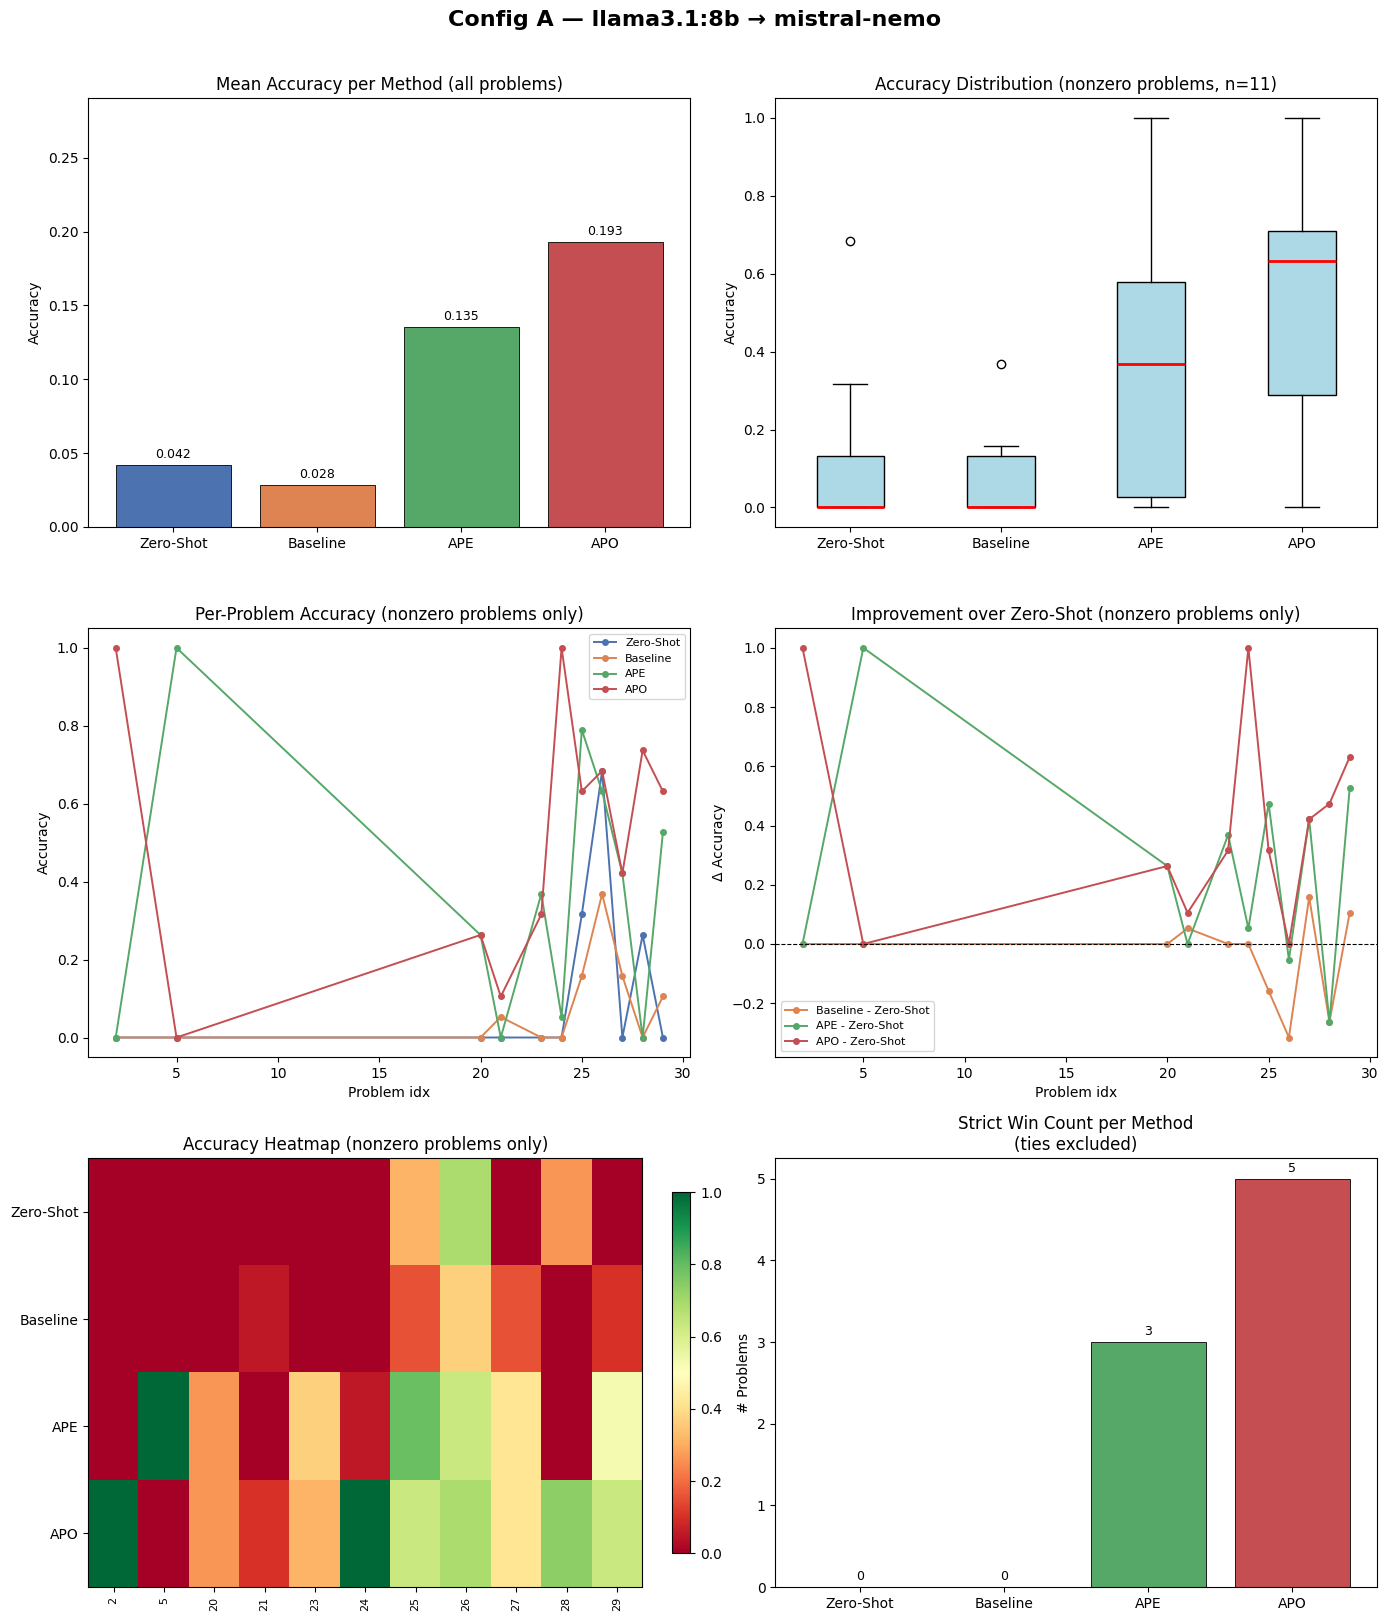

In [21]:
generate_graph(df_A, 'Config A — llama3.1:8b → mistral-nemo',
               save_path=os.path.join(BASE, 'outputs', 'config_A.png'))

---
## Config B — mistral-nemo (Optimizer) → llama3.1:8b (Target)

In [22]:
df_B = dfs['Config B — Nemo → llama3.1']
print(df_B[METHODS].describe().round(3))
df_B.head(10)

       accuracy_zero_shot  baseline     APE     APO
count              30.000    30.000  30.000  30.000
mean                0.188     0.109   0.144   0.247
std                 0.378     0.290   0.295   0.390
min                 0.000     0.000   0.000   0.000
25%                 0.000     0.000   0.000   0.000
50%                 0.000     0.000   0.000   0.000
75%                 0.039     0.000   0.092   0.355
max                 1.000     1.000   1.000   1.000


,idx,difficulty,n_test_cases,original_problem,accuracy_zero_shot,baseline,APE,APO,APE_pass@1,APO_pass@1,APE_pass@3,APO_pass@3,APE_pass@5,APO_pass@5,APE_pass@10,APO_pass@10
0,0,introductory,1,You are given an array $a$ of length $n$ consi...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,1,introductory,1,$n$ robots have escaped from your laboratory! ...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
2,2,introductory,1,There are $n$ athletes in front of you. Athlet...,1.0,1.0,0.0,1.0,0.00,0.25,0.00,0.75,0.0,NaN,0.0,NaN
3,3,introductory,1,You are given an undirected unweighted graph c...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
4,4,introductory,1,We guessed a permutation $p$ consisting of $n$...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,NaN,0.0
5,5,introductory,1,Polycarp analyzes the prices of the new berPho...,1.0,1.0,0.0,1.0,0.00,0.75,0.00,1.00,0.0,NaN,0.0,NaN
6,6,introductory,1,You are given two strings $s$ and $t$ both of ...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,NaN,0.0
7,7,introductory,1,You have $n$ gifts and you want to give all of...,0.0,0.0,1.0,0.0,0.25,0.00,0.75,0.00,NaN,0.0,NaN,0.0
8,8,introductory,1,This problem is a version of problem D from th...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
9,9,introductory,1,The only difference between easy and hard vers...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,NaN,0.0


C:\Users\dernj\AppData\Local\Temp\ipykernel_17708\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\config_B.png


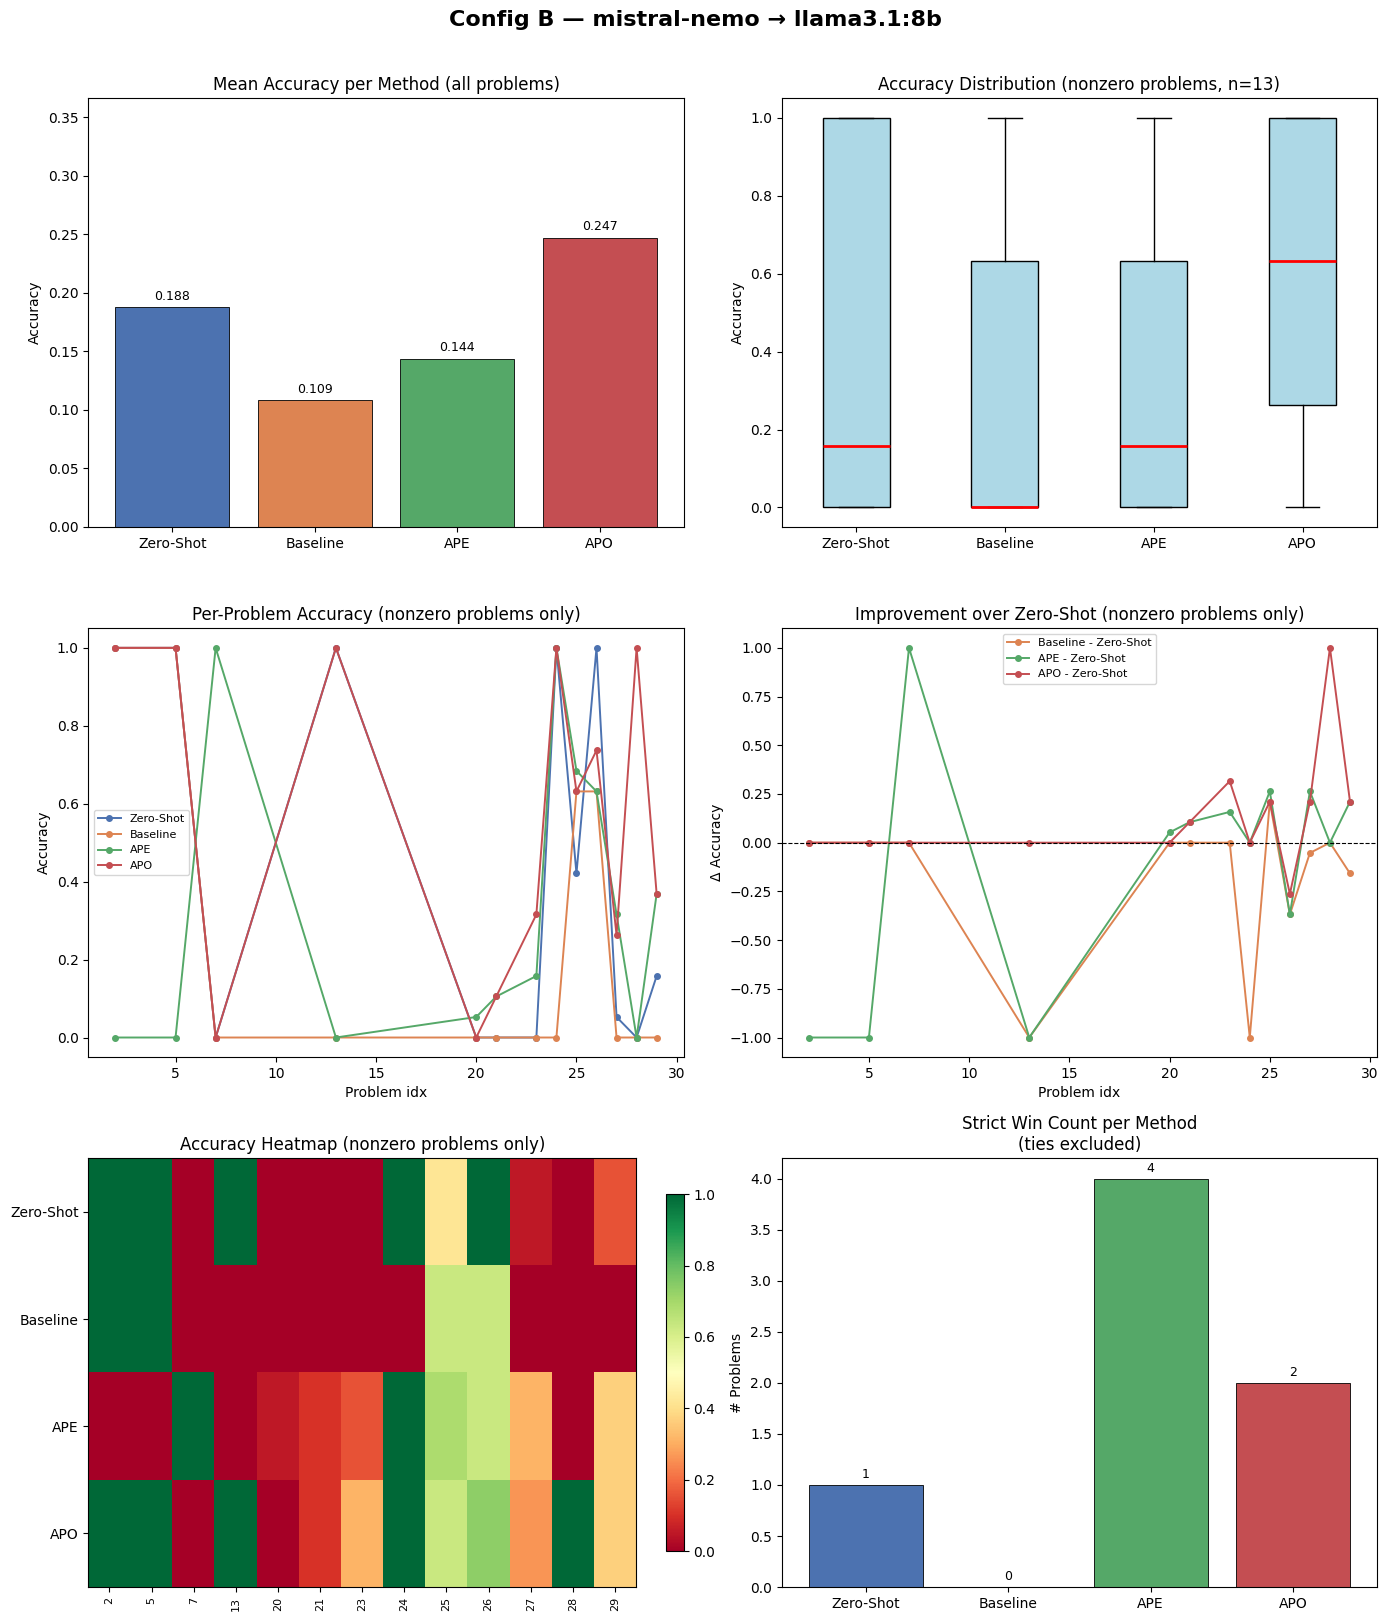

In [23]:
generate_graph(df_B, 'Config B — mistral-nemo → llama3.1:8b',
               save_path=os.path.join(BASE, 'outputs', 'config_B.png'))

---
## Config C — mistral-nemo → mistral-nemo (Self-Optimization)

In [24]:
df_C = dfs['Config C — Nemo → Nemo']
print(df_C[METHODS].describe().round(3))
df_C.head(10)

       accuracy_zero_shot  baseline     APE     APO
count              30.000    30.000  30.000  30.000
mean                0.061     0.051   0.146   0.186
std                 0.198     0.195   0.302   0.326
min                 0.000     0.000   0.000   0.000
25%                 0.000     0.000   0.000   0.000
50%                 0.000     0.000   0.000   0.000
75%                 0.000     0.000   0.079   0.263
max                 1.000     1.000   1.000   1.000


,idx,difficulty,n_test_cases,original_problem,accuracy_zero_shot,baseline,APE,APO,APE_pass@1,APO_pass@1,APE_pass@3,APO_pass@3,APE_pass@5,APO_pass@5,APE_pass@10,APO_pass@10
0,0,introductory,1,You are given an array $a$ of length $n$ consi...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
1,1,introductory,1,$n$ robots have escaped from your laboratory! ...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
2,2,introductory,1,There are $n$ athletes in front of you. Athlet...,1.0,0.0,1.0,0.0,0.0238,0.0,0.0714,0.0000,0.119,0.0000,0.2381,0.0000
3,3,introductory,1,You are given an undirected unweighted graph c...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
4,4,introductory,1,We guessed a permutation $p$ consisting of $n$...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
5,5,introductory,1,Polycarp analyzes the prices of the new berPho...,0.0,0.0,0.0,1.0,0.0000,0.2,0.0000,0.5088,0.000,0.7183,0.0000,0.9567
6,6,introductory,1,You are given two strings $s$ and $t$ both of ...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,NaN,0.0000
7,7,introductory,1,You have $n$ gifts and you want to give all of...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,NaN,0.0000
8,8,introductory,1,This problem is a version of problem D from th...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
9,9,introductory,1,The only difference between easy and hard vers...,0.0,0.0,0.0,0.0,0.0000,0.0,0.0000,0.0000,0.000,0.0000,NaN,0.0000


C:\Users\dernj\AppData\Local\Temp\ipykernel_17708\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\config_C.png


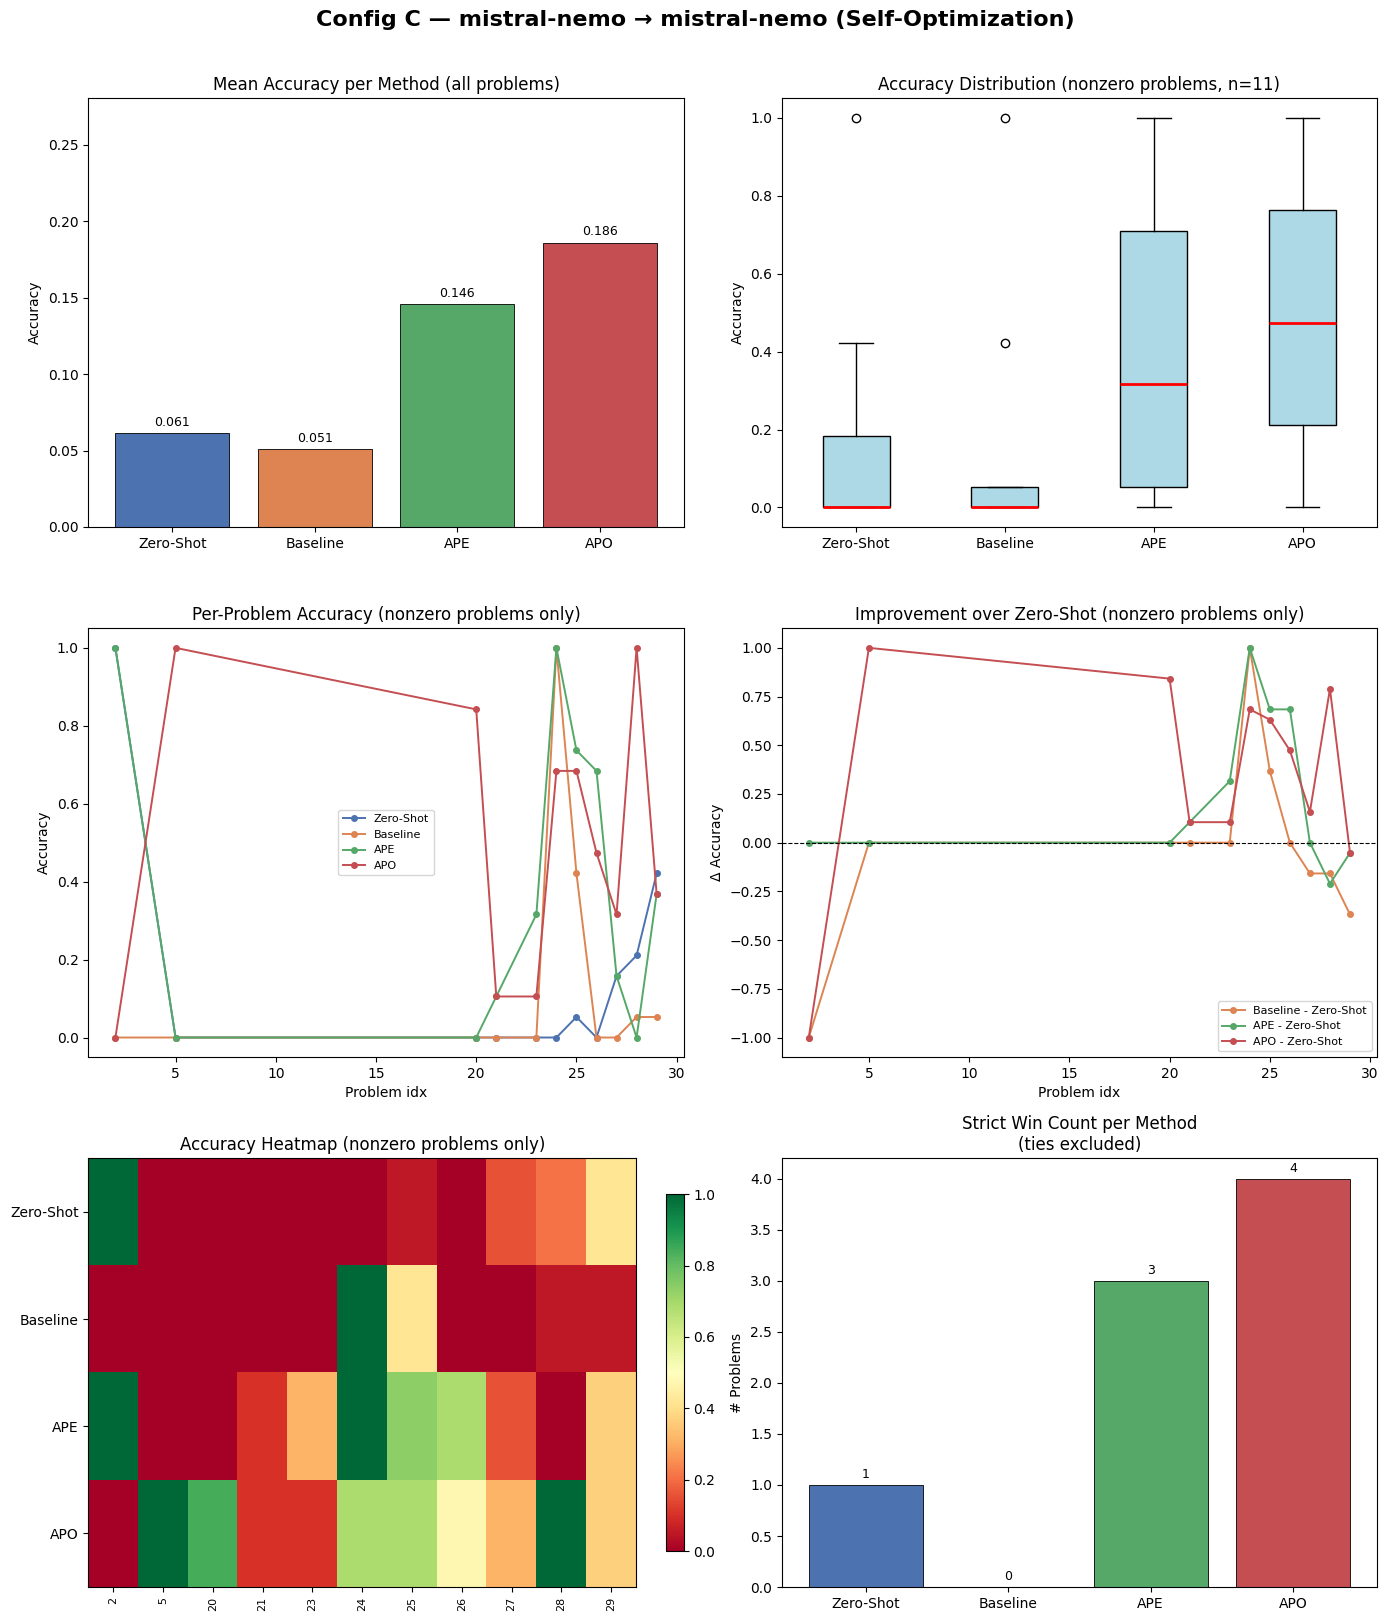

In [25]:
generate_graph(df_C, 'Config C — mistral-nemo → mistral-nemo (Self-Optimization)',
               save_path=os.path.join(BASE, 'outputs', 'config_C.png'))

---
## Config D — gemma2:9b → phi3:medium



In [26]:
print(f'Problemi disponibili: {len(df_D)}/30')
print(df_D[METHODS].describe().round(3))
df_D.head(10)

Problemi disponibili: 30/30
       accuracy_zero_shot  baseline     APE     APO
count              30.000    30.000  30.000  30.000
mean                0.211     0.156   0.244   0.318
std                 0.363     0.330   0.389   0.428
min                 0.000     0.000   0.000   0.000
25%                 0.000     0.000   0.000   0.000
50%                 0.000     0.000   0.000   0.000
75%                 0.342     0.000   0.579   0.750
max                 1.000     1.000   1.000   1.000


,idx,difficulty,n_test_cases,original_problem,accuracy_zero_shot,baseline,APE,APO,APE_pass@1,APO_pass@1,APE_pass@3,APO_pass@3,APE_pass@5,APO_pass@5,APE_pass@10,APO_pass@10
0,0,introductory,1,You are given an array $a$ of length $n$ consi...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,NaN,0.0,NaN,0.0
1,1,introductory,1,$n$ robots have escaped from your laboratory! ...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,0.0,0.0
2,2,introductory,1,There are $n$ athletes in front of you. Athlet...,0.0,0.0,0.0,1.0,0.0000,0.25,0.0000,0.75,0.0000,NaN,0.0,NaN
3,3,introductory,1,You are given an undirected unweighted graph c...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,0.0,0.0
4,4,introductory,1,We guessed a permutation $p$ consisting of $n$...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,0.0,0.0
5,5,introductory,1,Polycarp analyzes the prices of the new berPho...,1.0,1.0,1.0,1.0,0.9091,1.00,1.0000,1.00,1.0000,NaN,1.0,NaN
6,6,introductory,1,You are given two strings $s$ and $t$ both of ...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,NaN,0.0
7,7,introductory,1,You have $n$ gifts and you want to give all of...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,0.0,0.0
8,8,introductory,1,This problem is a version of problem D from th...,0.0,0.0,0.0,0.0,0.0000,0.00,0.0000,0.00,0.0000,0.0,0.0,0.0
9,9,introductory,1,The only difference between easy and hard vers...,0.0,0.0,1.0,0.0,0.2727,0.00,0.6606,0.00,0.8788,0.0,1.0,0.0


C:\Users\dernj\AppData\Local\Temp\ipykernel_17708\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\config_D.png


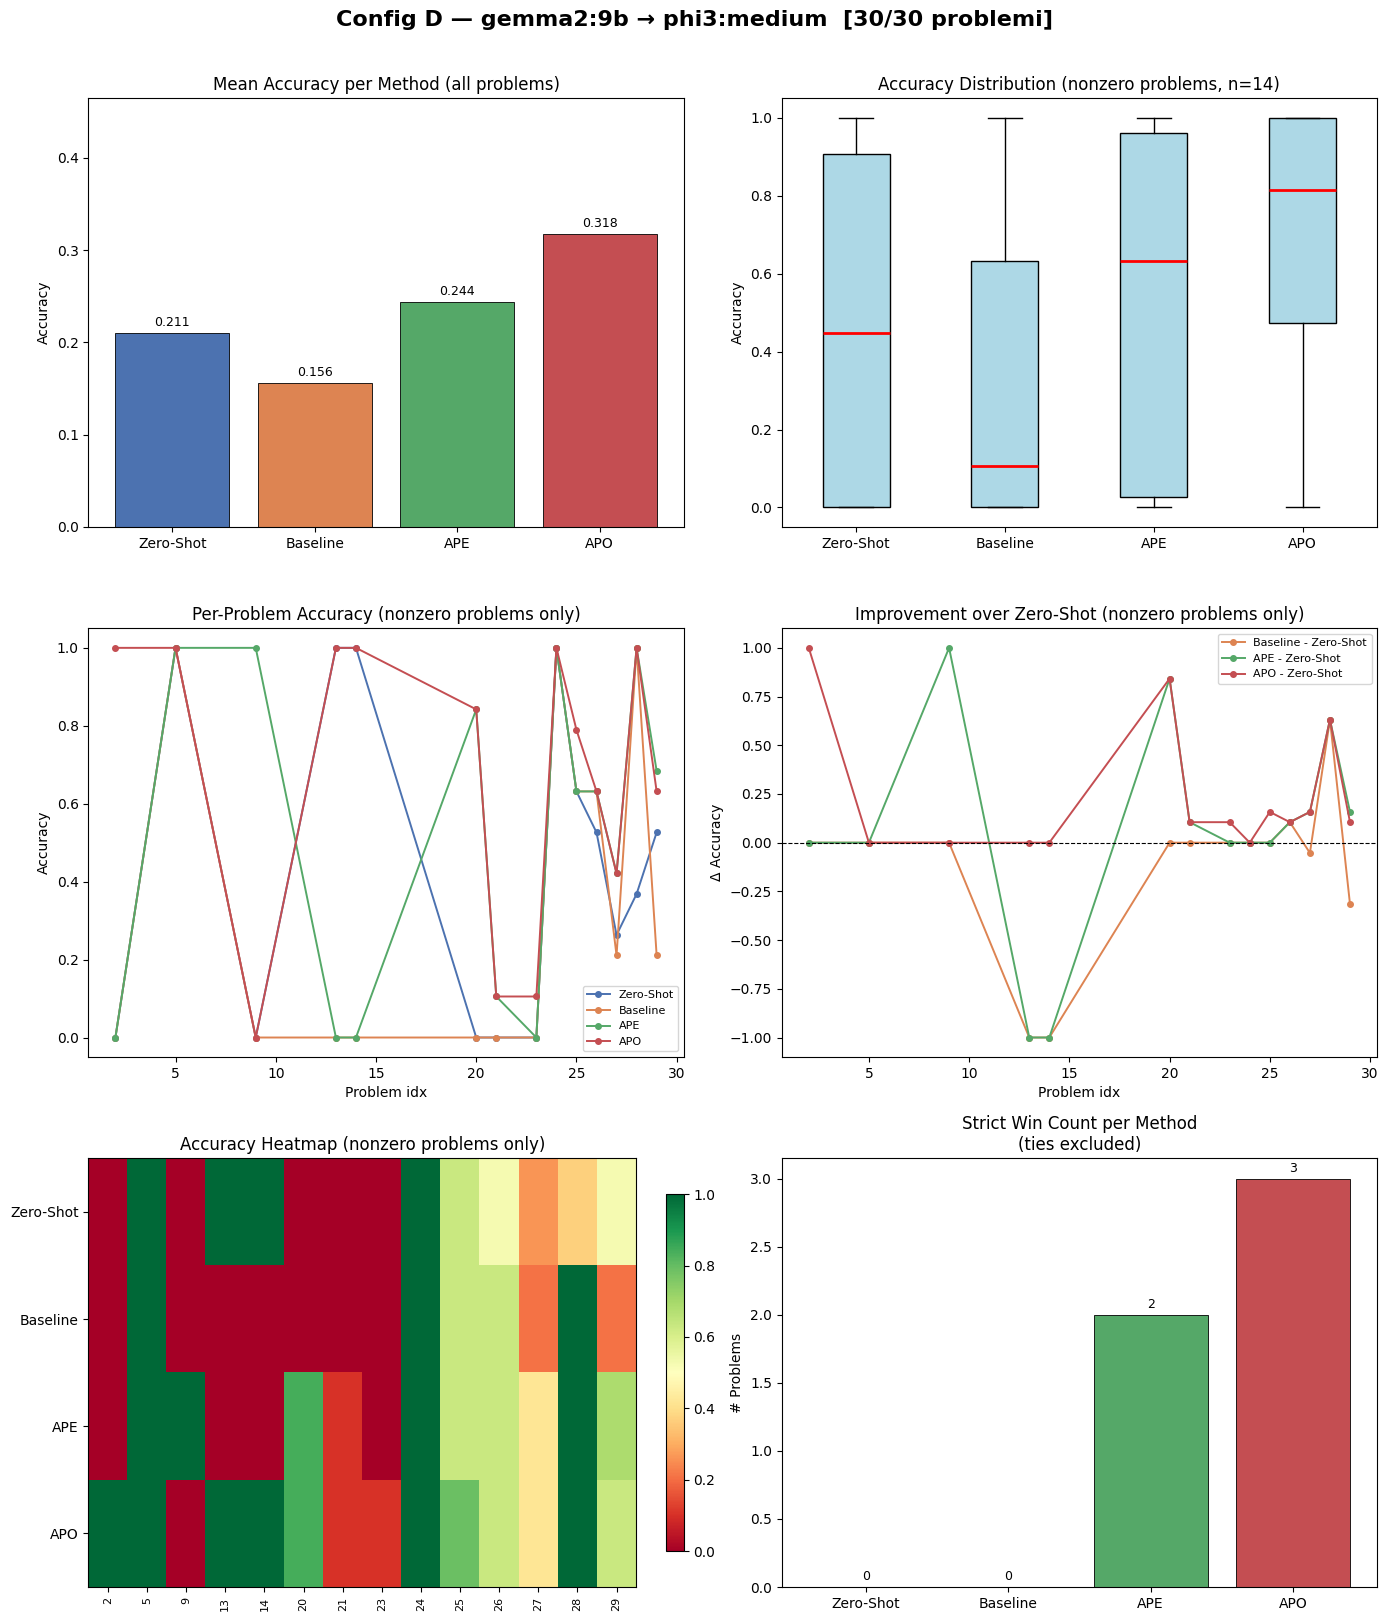

In [27]:
generate_graph(df_D, f'Config D — gemma2:9b → phi3:medium  [{len(df_D)}/30 problemi]',
               save_path=os.path.join(BASE, 'outputs', 'config_D.png'))

---
## Confronto tra tutte le configurazioni

In [7]:
cfg_labels = [
    ('A: llama3.1→Nemo',      df_A,  False),
    ('B: Nemo→llama3.1',      df_B,  False),
    ('C: Nemo→Nemo',          df_C,  False),
    ('D: gemma2:9b→phi3:medium',   df_D,  True),
]

# --- Tabella riassuntiva mean accuracy ---
summary = pd.DataFrame([
    {'Config': lbl, **{m: df[m].mean() for m in METHODS}}
    for lbl, df, _ in cfg_labels
]).set_index('Config').rename(columns=dict(zip(METHODS, LABELS)))

print('=== Mean Accuracy per Config ===' )
print(summary.round(4).to_string())
summary

NameError: name 'df_A' is not defined

NameError: name 'LABELS' is not defined

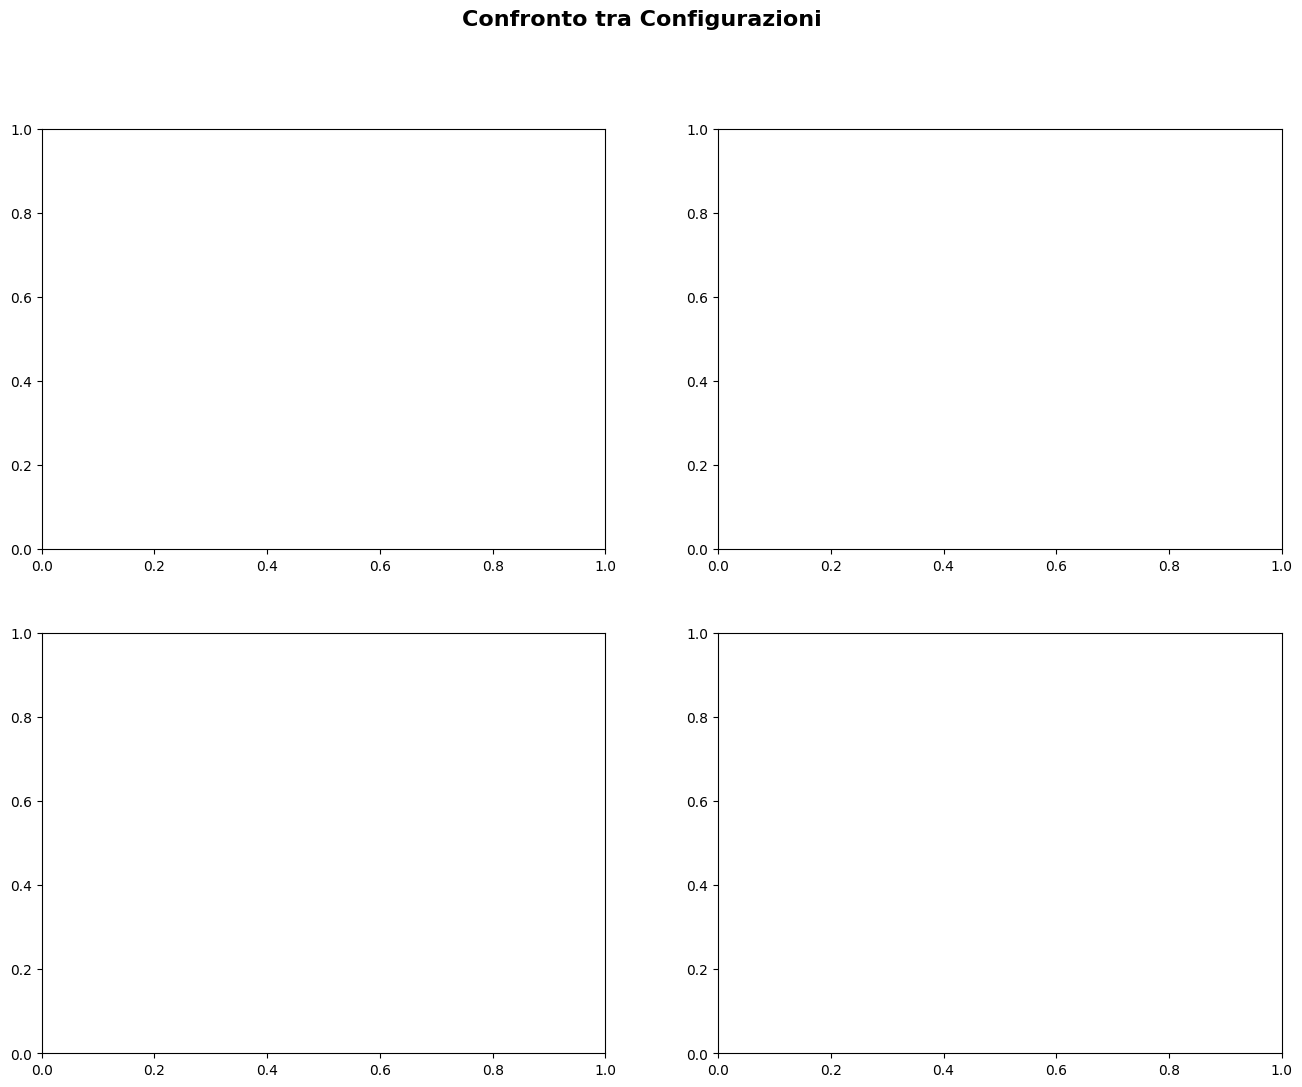

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confronto tra Configurazioni', fontsize=16, fontweight='bold')

cfg_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- 1. Grouped bar: mean accuracy per method per config ---
ax = axes[0, 0]
x = np.arange(len(LABELS))
width = 0.2
for i, (lbl, df, partial) in enumerate(cfg_labels):
    means = [df[m].mean() for m in METHODS]
    suffix = ' *' if partial else ''
    bars = ax.bar(x + i * width, means, width, label=lbl + suffix,
                  color=cfg_colors[i], edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(LABELS)
ax.set_title('Mean Accuracy per Method e Config')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
ax.text(0.01, 0.97, '* parziale', transform=ax.transAxes, fontsize=7, va='top', color='gray')

# --- 2. APO best accuracy confronto ---
ax = axes[0, 1]
for i, (lbl, df, partial) in enumerate(cfg_labels):
    suffix = ' *' if partial else ''
    ax.plot(df['idx'], df['APO'], label=lbl + suffix,
            color=cfg_colors[i], marker='o', markersize=3, linewidth=1.4)
ax.set_title('APO Best Accuracy per Config (per problema)')
ax.set_xlabel('Problem idx')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)

# --- 3. APO vs APE mean per config ---
ax = axes[1, 0]
cfg_names = [lbl for lbl, _, _ in cfg_labels]
ape_means  = [df['APE'].mean() for _, df, _ in cfg_labels]
apo_means  = [df['APO'].mean() for _, df, _ in cfg_labels]
x2 = np.arange(len(cfg_names))
ax.bar(x2 - 0.2, ape_means, 0.4, label='APE', color='#55A868', edgecolor='black', linewidth=0.5)
ax.bar(x2 + 0.2, apo_means, 0.4, label='APO', color='#C44E52', edgecolor='black', linewidth=0.5)
ax.set_xticks(x2)
ax.set_xticklabels([c.split(':')[0] for c in cfg_names], fontsize=9)
ax.set_title('APE vs APO Mean Accuracy per Config')
ax.set_ylabel('Accuracy')
ax.legend()

# --- 4. Heatmap: mean accuracy [config x method] ---
ax = axes[1, 1]
heat = summary.values
im = ax.imshow(heat, cmap='RdYlGn', vmin=0, vmax=heat.max() + 0.05, aspect='auto')
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(cfg_names)))
ax.set_yticklabels([c.split(':')[0] for c in cfg_names], fontsize=9)
for i in range(len(cfg_names)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{heat[i, j]:.3f}', ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_title('Heatmap Mean Accuracy [Config × Method]')
plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'confronto_configurazioni.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Analisi Pass@k — APE e APO per ogni configurazione

In [8]:

cfg_labels = [
    ('A: llama3.1→Nemo',   df_A, False),
    ('B: Nemo→llama3.1',   df_B, False),
    ('C: Nemo→Nemo',       df_C, False),
    ('D: Gemma2:9b→phi3:medium',       df_D, True),
]
cfg_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Tabella riassuntiva pass@k mean per ogni config ---
passk_cols_ape = [f'APE_pass@{k}' for k in PASS_K_VALUES]
passk_cols_apo = [f'APO_pass@{k}' for k in PASS_K_VALUES]

rows_summary = []
for lbl, df, partial in cfg_labels:
    for method, cols in [('APE', passk_cols_ape), ('APO', passk_cols_apo)]:
        row = {'Config': lbl, 'Method': method}
        for col in cols:
            k = col.split('@')[1]
            row[f'pass@{k}'] = df[col].mean(skipna=True)
        rows_summary.append(row)

summary_passk = pd.DataFrame(rows_summary).set_index(['Config', 'Method'])
print('=== Mean Pass@k per Config e Metodo ===')
print(summary_passk.round(4).to_string())
summary_passk


NameError: name 'df_A' is not defined

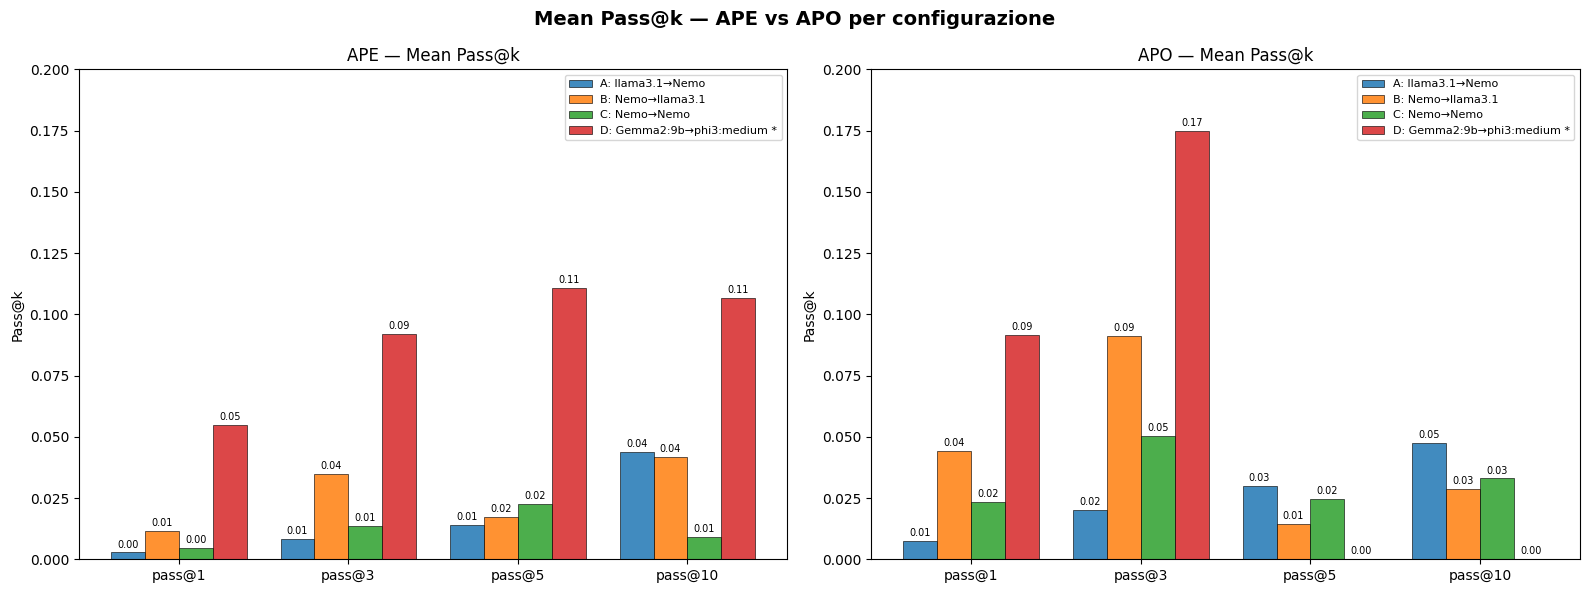

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean Pass@k — APE vs APO per configurazione', fontsize=14, fontweight='bold')

ks = [str(k) for k in PASS_K_VALUES]

for ax, method, cols in zip(axes, ['APE', 'APO'], [passk_cols_ape, passk_cols_apo]):
    x = np.arange(len(ks))
    width = 0.2
    for i, (lbl, df, partial) in enumerate(cfg_labels):
        means = [df[col].mean(skipna=True) for col in cols]
        suffix = ' *' if partial else ''
        bars = ax.bar(x + i * width, means, width, label=lbl + suffix,
                      color=cfg_colors[i], edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7)
    ax.set_title(f'{method} — Mean Pass@k')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'pass@{k}' for k in ks])
    ax.set_ylabel('Pass@k')
    ax.set_ylim(0, 0.2)
    ax.legend(fontsize=8)
    ax.text(0.01, 0.97, '', transform=ax.transAxes, fontsize=7, va='top', color='gray')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'passk_confronto.png'), bbox_inches='tight', dpi=150)
plt.show()


In [9]:
import pandas as pd

df = pd.read_json('../results_20260331_215205.json')
df.head()

APE_result = df['APE']
APO_result = df['APO']



FileNotFoundError: File ../results_20260331_215205.json does not exist

---
## Nuovi Risultati — results_20260331_215205

| Difficoltà | N |
|------------|---|
| introductory | 10 |
| interview | 20 |
| competition | 15 |

In [10]:
import os
import pandas as pd
import numpy as np

In [11]:
BASE = os.path.dirname(CWD) if os.path.basename(CWD) == 'notebooks' else CWD
METHODS = ['accuracy_zero_shot', 'baseline', 'APE', 'APO']
LABELS  = ['Zero-Shot', 'Baseline', 'APE', 'APO']

In [12]:
# ── Parsing nuovi risultati ──────────────────────────────────────────────────
def load_results(path):
    with open(path, encoding='utf-8') as f:
        raw = json.load(f)
    rows = []
    for x in raw:
        row = {
            'idx':                x['problem_idx'],
            'difficulty':         x['difficulty'],
            'n_test_cases':       x['n_test_cases'],
            'accuracy_zero_shot': x['zero_shot']['accuracy'],
            'baseline':           x['baseline']['accuracy'],
            'APE':                x['APE']['best_accuracy'],
            'APO':                x['APO']['best_accuracy'],
        }
        for k in PASS_K_VALUES:
            row[f'APE_pass@{k}'] = x['APE'].get('pass_at_k', {}).get(f'pass@{k}', np.nan)
            row[f'APO_pass@{k}'] = x['APO'].get('pass_at_k', {}).get(f'pass@{k}', np.nan)
        rows.append(row)
    return pd.DataFrame(rows)

df_new = load_results(os.path.join(BASE, 'results_20260331_215205.json'))
print(f'Totale problemi: {len(df_new)}')
print()
print(df_new.groupby('difficulty')[METHODS].mean().round(3).to_string())
print()
df_new[METHODS].describe().round(3)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\dernj\\Desktop\\Tesi_esperimenti\\results_20260331_215205.json'

C:\Users\dernj\AppData\Local\Temp\ipykernel_30208\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\new_results_overall.png


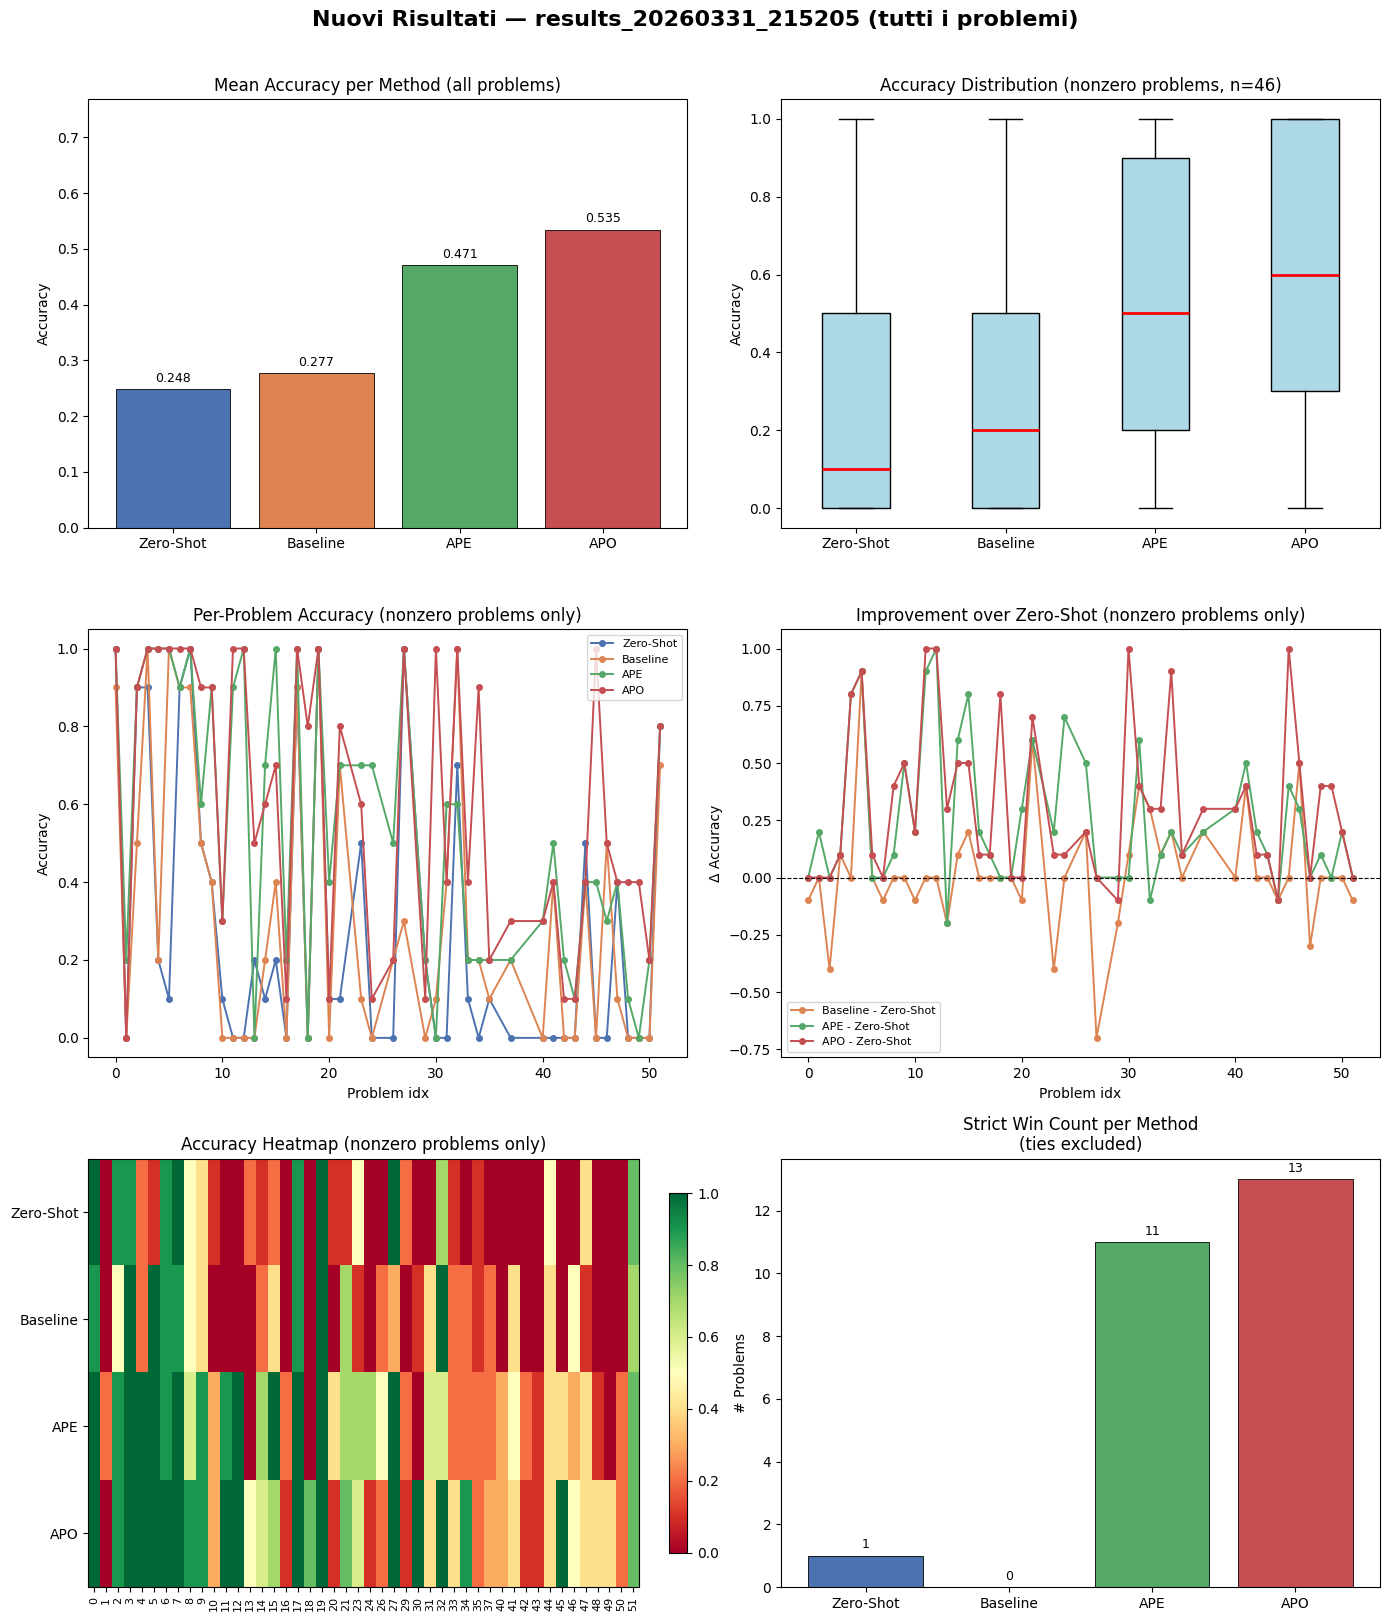

In [ ]:
generate_graph(
    df_new,
    'Nuovi Risultati — results_20260331_215205 (tutti i problemi)',
    save_path=os.path.join(BASE, 'outputs', 'new_results_overall.png'),
)

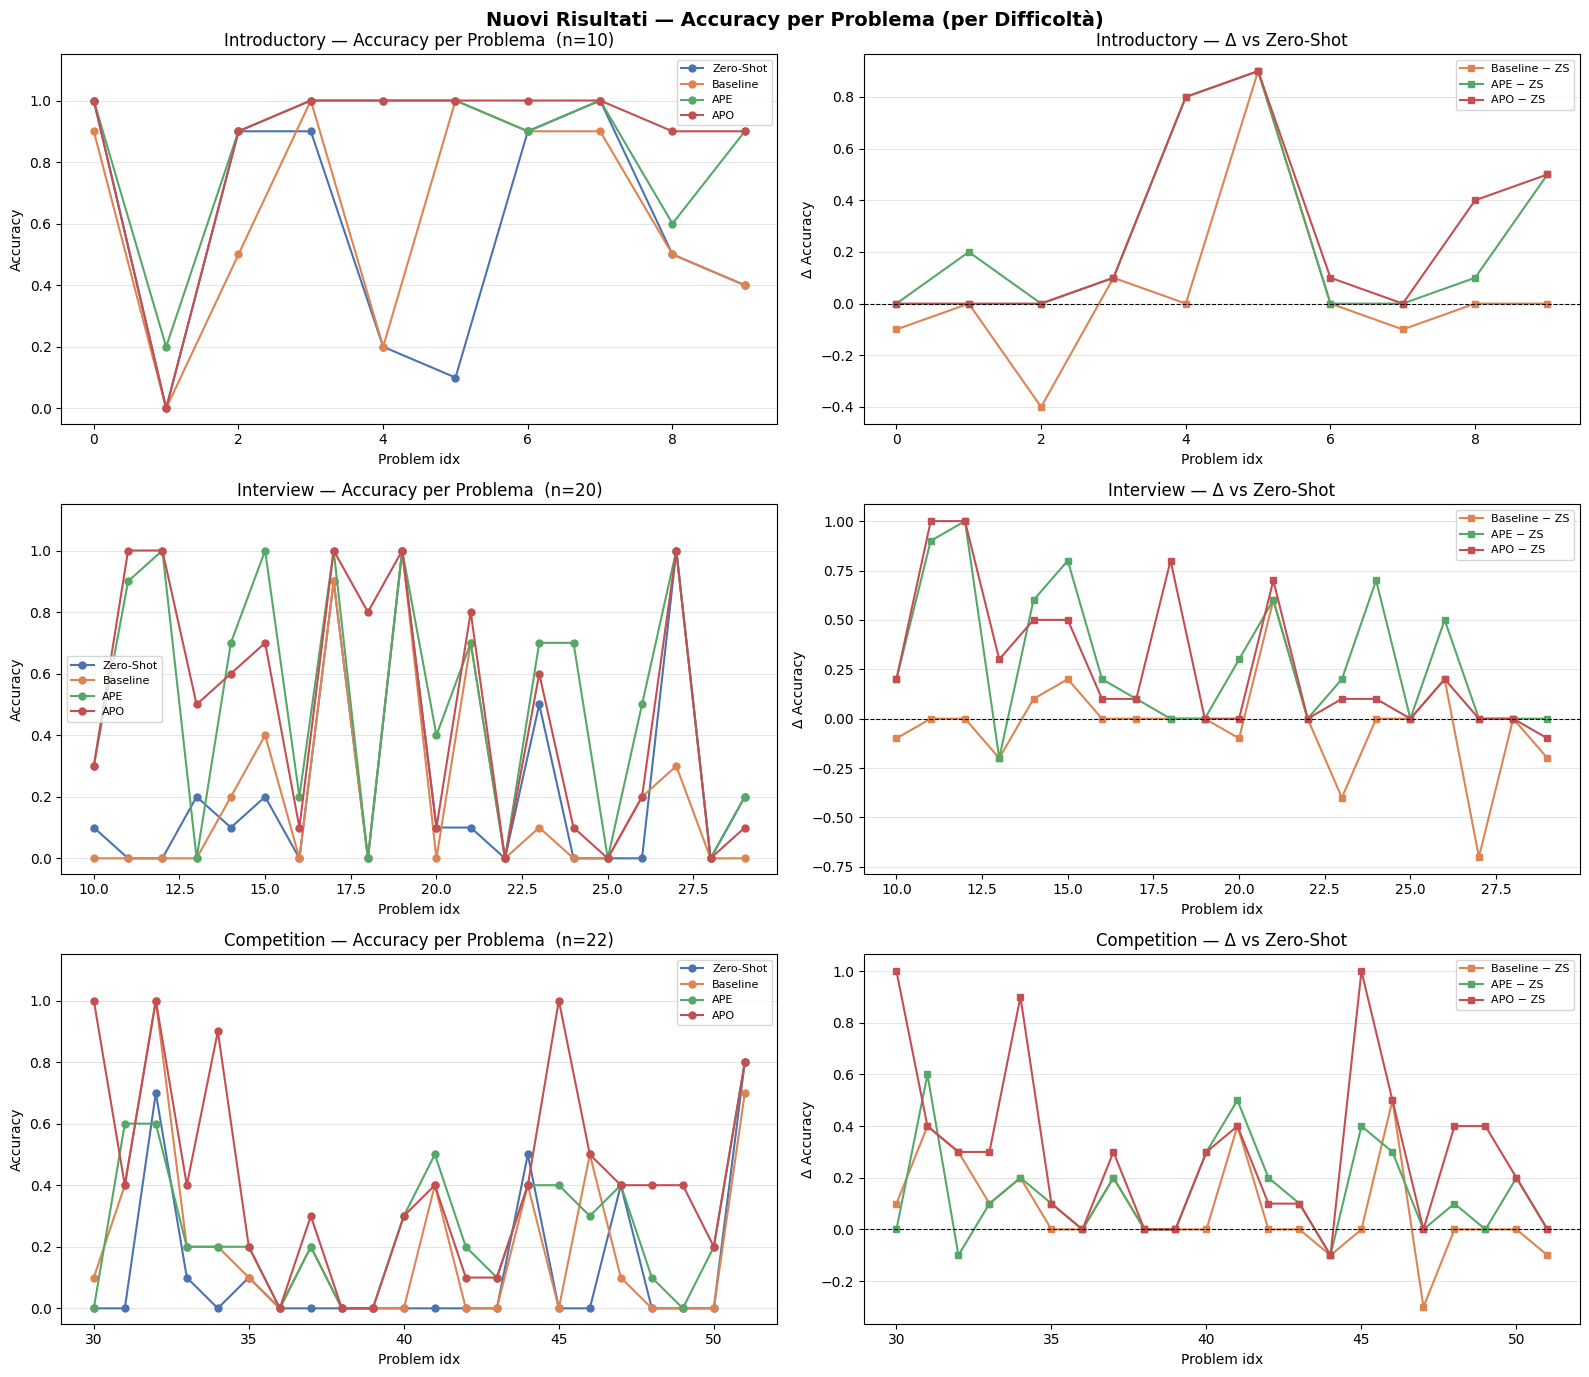

In [ ]:
diffs        = ['introductory', 'interview', 'competition']
diff_palette = ['#2ecc71',      '#3498db',   '#e74c3c']

fig, axes = plt.subplots(len(diffs), 2, figsize=(16, 14))
fig.suptitle(
    'Nuovi Risultati — Accuracy per Problema (per Difficoltà)',
    fontsize=14, fontweight='bold',
)

for row_idx, (diff, dc) in enumerate(zip(diffs, diff_palette)):
    sub = df_new[df_new['difficulty'] == diff].copy()

    a
    ax = axes[row_idx, 0]
    for m, lbl, c in zip(METHODS, LABELS, COLORS):
        ax.plot(sub['idx'], sub[m], label=lbl, color=c,
                marker='o', markersize=5, linewidth=1.5)
    ax.set_title(f'{diff.capitalize()} — Accuracy per Problema  (n={len(sub)})')
    ax.set_xlabel('Problem idx')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.6)

    
    ax = axes[row_idx, 1]
    for m, lbl, c in zip(METHODS[1:], LABELS[1:], COLORS[1:]):
        ax.plot(sub['idx'], sub[m] - sub['accuracy_zero_shot'],
                label=f'{lbl} − ZS', color=c,
                marker='s', markersize=5, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{diff.capitalize()} — Δ vs Zero-Shot')
    ax.set_xlabel('Problem idx')
    ax.set_ylabel('Δ Accuracy')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE, 'outputs', 'new_results_per_difficulty.png'),
    bbox_inches='tight', dpi=150,
)
plt.show()

C:\Users\dernj\AppData\Local\Temp\ipykernel_30208\4293355439.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_new[m] for m in METHODS], labels=LABELS,


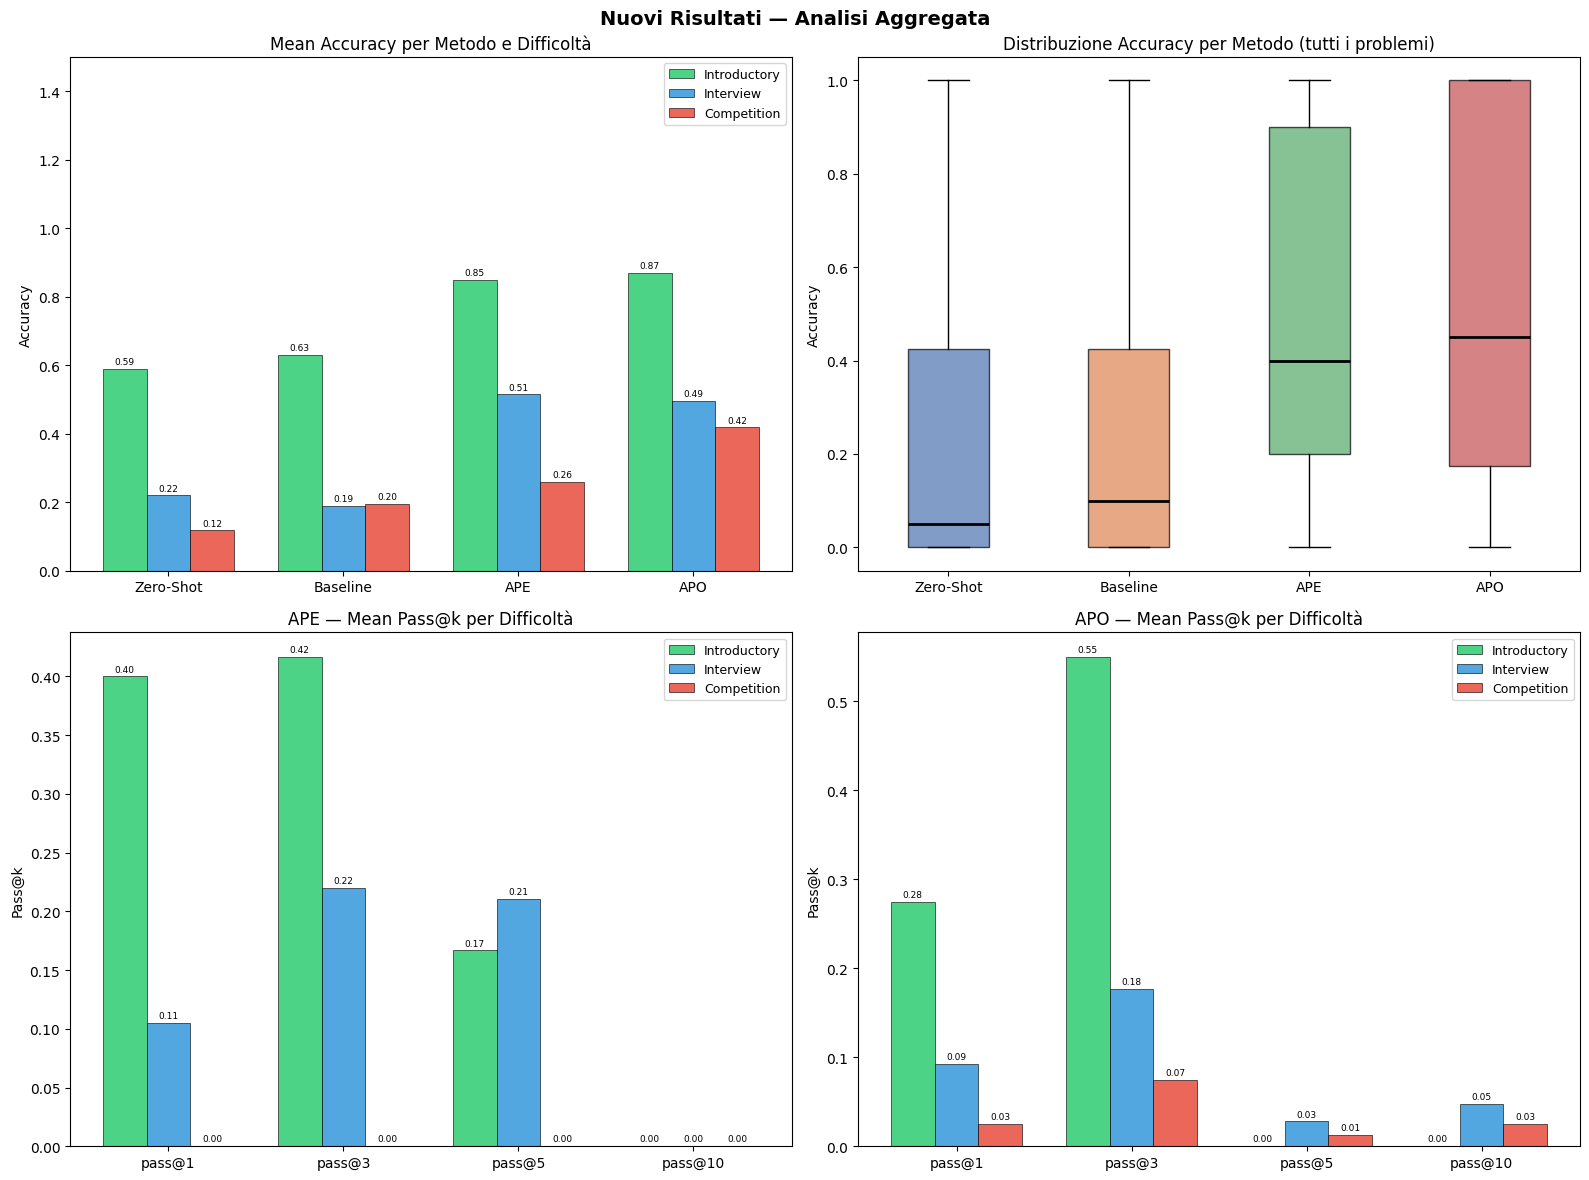

In [ ]:
diffs        = ['introductory', 'interview', 'competition']
diff_palette = ['#2ecc71',      '#3498db',   '#e74c3c']
passk_cols_ape = [f'APE_pass@{k}' for k in PASS_K_VALUES]
passk_cols_apo = [f'APO_pass@{k}' for k in PASS_K_VALUES]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Nuovi Risultati — Analisi Aggregata', fontsize=14, fontweight='bold')


ax = axes[0, 0]
x  = np.arange(len(LABELS))
w  = 0.25
for i, (diff, dc) in enumerate(zip(diffs, diff_palette)):
    sub   = df_new[df_new['difficulty'] == diff]
    means = [sub[m].mean() for m in METHODS]
    bars  = ax.bar(x + (i - 1) * w, means, w, label=diff.capitalize(),
                   color=dc, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=6.5)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_title('Mean Accuracy per Metodo e Difficoltà')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=9)
ax.set_ylim(0, df_new[METHODS].max().max() * 1.45 + 0.05)


ax = axes[0, 1]
bp = ax.boxplot([df_new[m] for m in METHODS], labels=LABELS,
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], COLORS):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_title('Distribuzione Accuracy per Metodo (tutti i problemi)')
ax.set_ylabel('Accuracy')

ax  = axes[1, 0]
x3  = np.arange(len(PASS_K_VALUES))
for i, (diff, dc) in enumerate(zip(diffs, diff_palette)):
    sub   = df_new[df_new['difficulty'] == diff]
    means = [sub[f'APE_pass@{k}'].mean(skipna=True) for k in PASS_K_VALUES]
    bars  = ax.bar(x3 + (i - 1) * w, means, w, label=diff.capitalize(),
                   color=dc, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=6.5)
ax.set_xticks(x3)
ax.set_xticklabels([f'pass@{k}' for k in PASS_K_VALUES])
ax.set_title('APE — Mean Pass@k per Difficoltà')
ax.set_ylabel('Pass@k')
ax.legend(fontsize=9)


ax = axes[1, 1]
for i, (diff, dc) in enumerate(zip(diffs, diff_palette)):
    sub   = df_new[df_new['difficulty'] == diff]
    means = [sub[f'APO_pass@{k}'].mean(skipna=True) for k in PASS_K_VALUES]
    bars  = ax.bar(x3 + (i - 1) * w, means, w, label=diff.capitalize(),
                   color=dc, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=6.5)
ax.set_xticks(x3)
ax.set_xticklabels([f'pass@{k}' for k in PASS_K_VALUES])
ax.set_title('APO — Mean Pass@k per Difficoltà')
ax.set_ylabel('Pass@k')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(BASE, 'outputs', 'new_results_aggregated.png'),
    bbox_inches='tight', dpi=150,
)
plt.show()

---
## Analisi APPS + HumanEval — Confronto per Difficoltà

Benchmarks: **APPS** (con fasce: introductory / interview / competition) e **HumanEval** (senza difficoltà).

| Config | Optimizer | Target |
|--------|-----------|--------|
| A | llama3.1:8b   | mistral-nemo  |
| B | mistral-nemo  | llama3.1:8b   |
| C | mistral-nemo  | mistral-nemo  |


In [16]:
# ── APPS + HumanEval: loader ─────────────────────────────────────────────
APPS_CONFIGS = [
    ('A: llama3.1→Nemo',  os.path.join(BASE, 'result', 'llama3.1-nemo_APPS.json'), '#1f77b4'),
    ('B: Nemo→llama3.1',  os.path.join(BASE, 'result', 'nemo-llama3.1_APPS.json'), '#ff7f0e'),
    ('C: Nemo→Nemo',      os.path.join(BASE, 'result', 'nemo-nemo_APPS.json'),     '#2ca02c'),
]
HEVAL_CONFIGS = [
    ('A: llama3.1→Nemo',  os.path.join(BASE, 'result', 'llama3.1-nemo_HEval.json'), '#1f77b4'),
    ('B: Nemo→llama3.1',  os.path.join(BASE, 'result', 'nemo-llama3.1_HEval.json'), '#ff7f0e'),
    ('C: Nemo→Nemo',      os.path.join(BASE, 'result', 'nemo-nemo_HEval.json'),     '#2ca02c'),
]


def load_bench(path, has_difficulty=True):
    with open(path, encoding='utf-8') as f:
        raw = json.load(f)
    rows = []
    for x in raw:
        row = {
            'idx':                x['problem_idx'],
            'n_test_cases':       x['n_test_cases'],
            'accuracy_zero_shot': x['zero_shot']['accuracy'],
            'baseline':           x['baseline']['accuracy'],
            'APE':                x['APE']['best_accuracy'],
            'APO':                x['APO']['best_accuracy'],
        }
        if has_difficulty:
            row['difficulty'] = x['difficulty']
        for k in PASS_K_VALUES:
            row[f'APE_pass@{k}'] = x['APE'].get('pass_at_k', {}).get(f'pass@{k}', np.nan)
            row[f'APO_pass@{k}'] = x['APO'].get('pass_at_k', {}).get(f'pass@{k}', np.nan)
        rows.append(row)
    return pd.DataFrame(rows)


apps_dfs  = {lbl: load_bench(p, has_difficulty=True)  for lbl, p, _ in APPS_CONFIGS}
heval_dfs = {lbl: load_bench(p, has_difficulty=False) for lbl, p, _ in HEVAL_CONFIGS}

print('── APPS ──')
for lbl, df in apps_dfs.items():
    counts = df['difficulty'].value_counts().to_dict()
    print(f'  {lbl:22s} {len(df):3d} problemi — {counts}')

print('\n── HumanEval ──')
for lbl, df in heval_dfs.items():
    print(f'  {lbl:22s} {len(df):3d} problemi')


── APPS ──
  A: llama3.1→Nemo        15 problemi — {'introductory': 5, 'interview': 5, 'competition': 5}
  B: Nemo→llama3.1        15 problemi — {'introductory': 5, 'interview': 5, 'competition': 5}
  C: Nemo→Nemo            15 problemi — {'introductory': 5, 'interview': 5, 'competition': 5}

── HumanEval ──
  A: llama3.1→Nemo        15 problemi
  B: Nemo→llama3.1        15 problemi
  C: Nemo→Nemo            15 problemi


### Visualizzazioni iniziali — APPS (per config)

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\apps_config_A.png


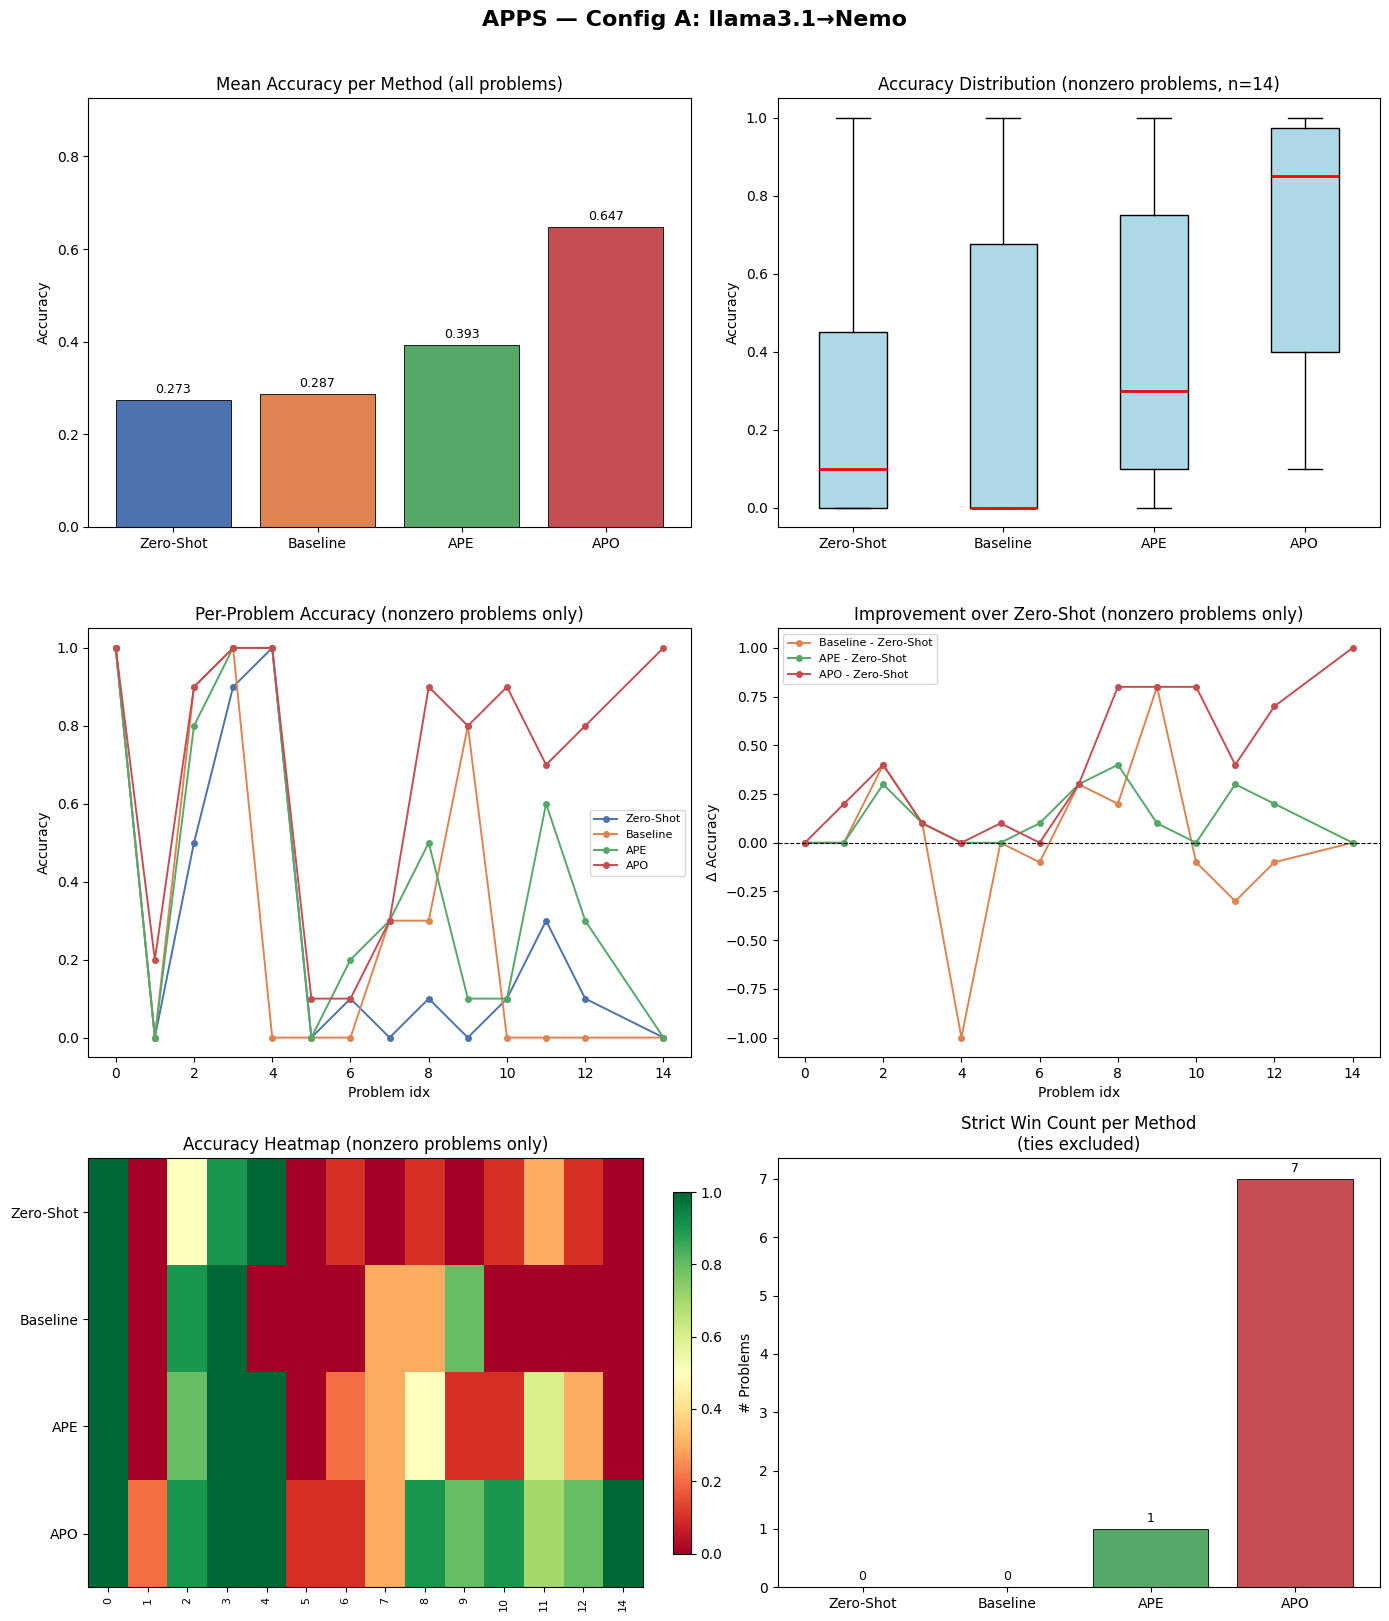

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\apps_config_B.png


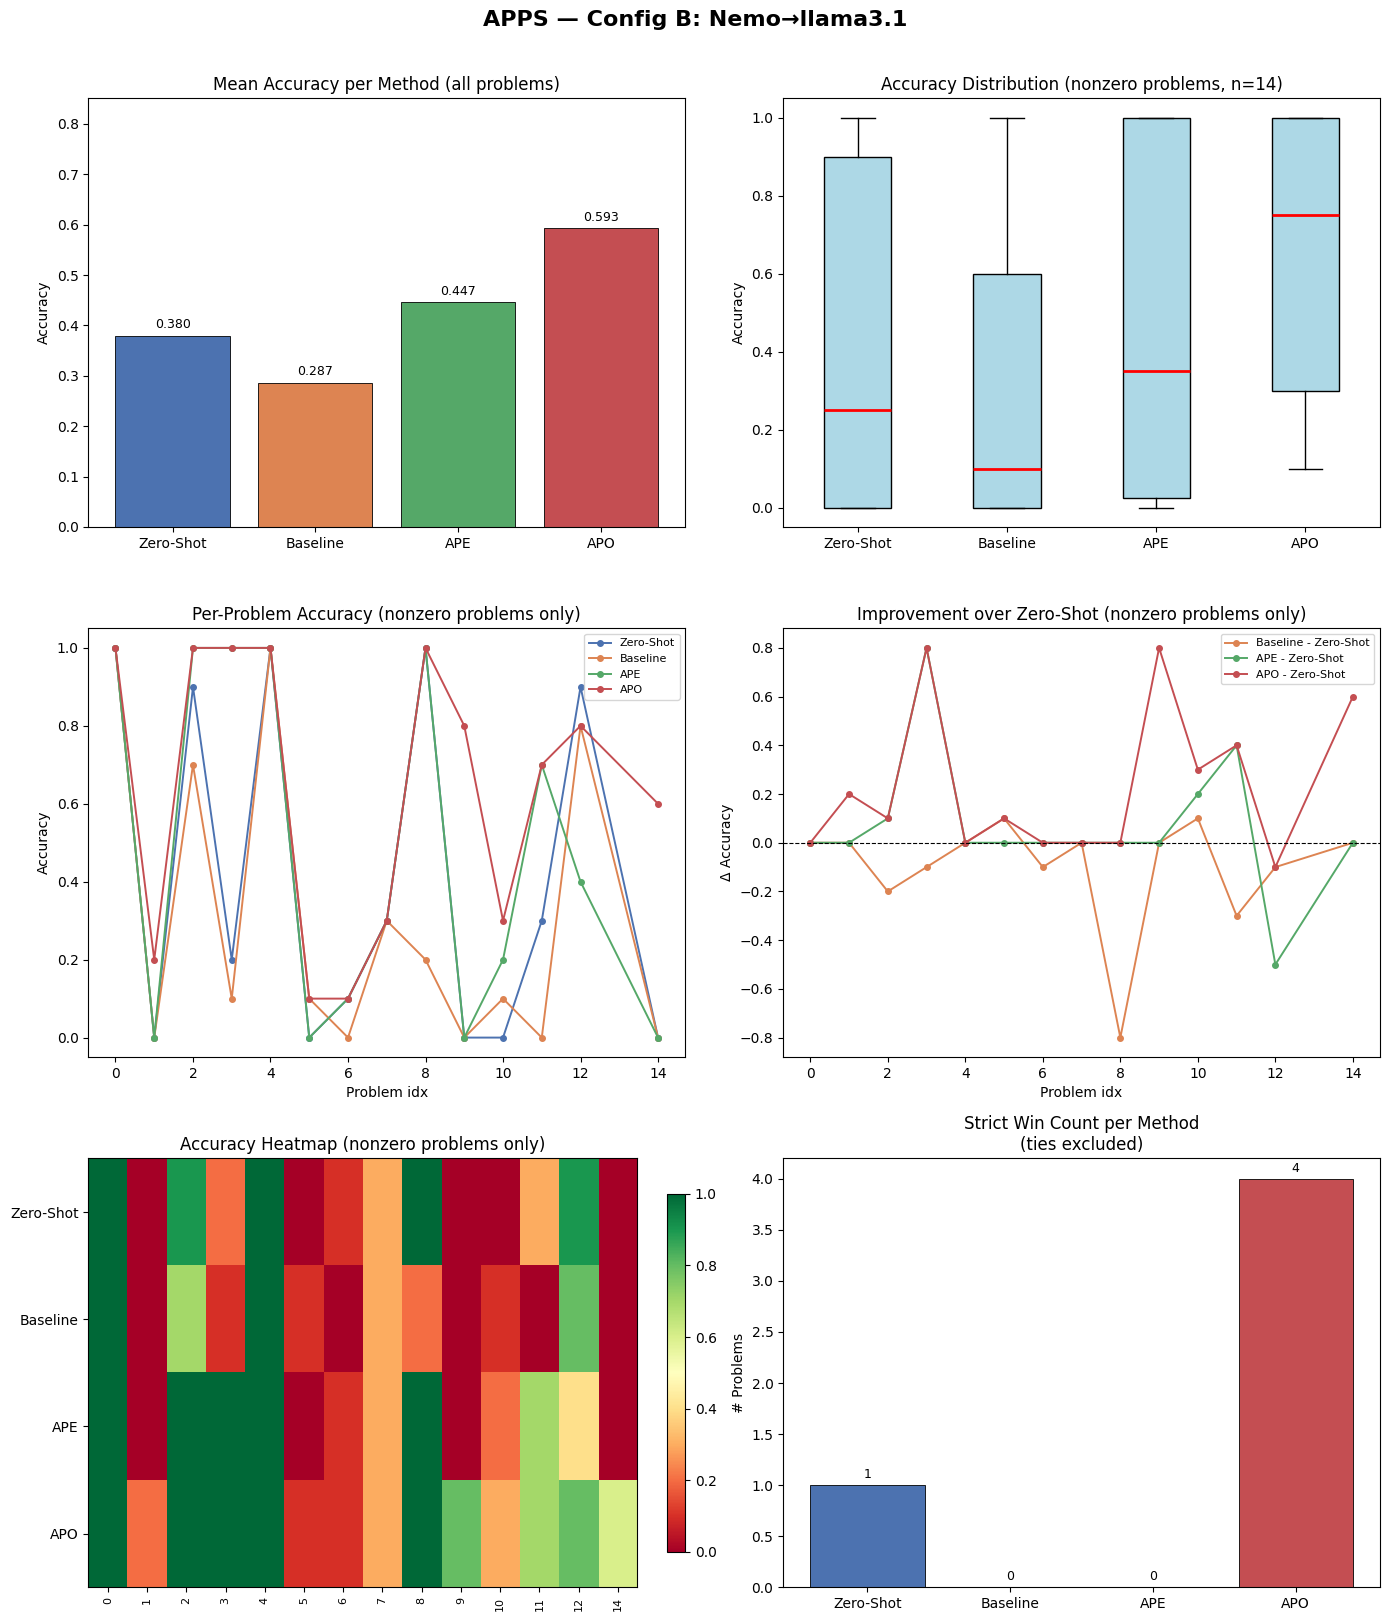

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\apps_config_C.png


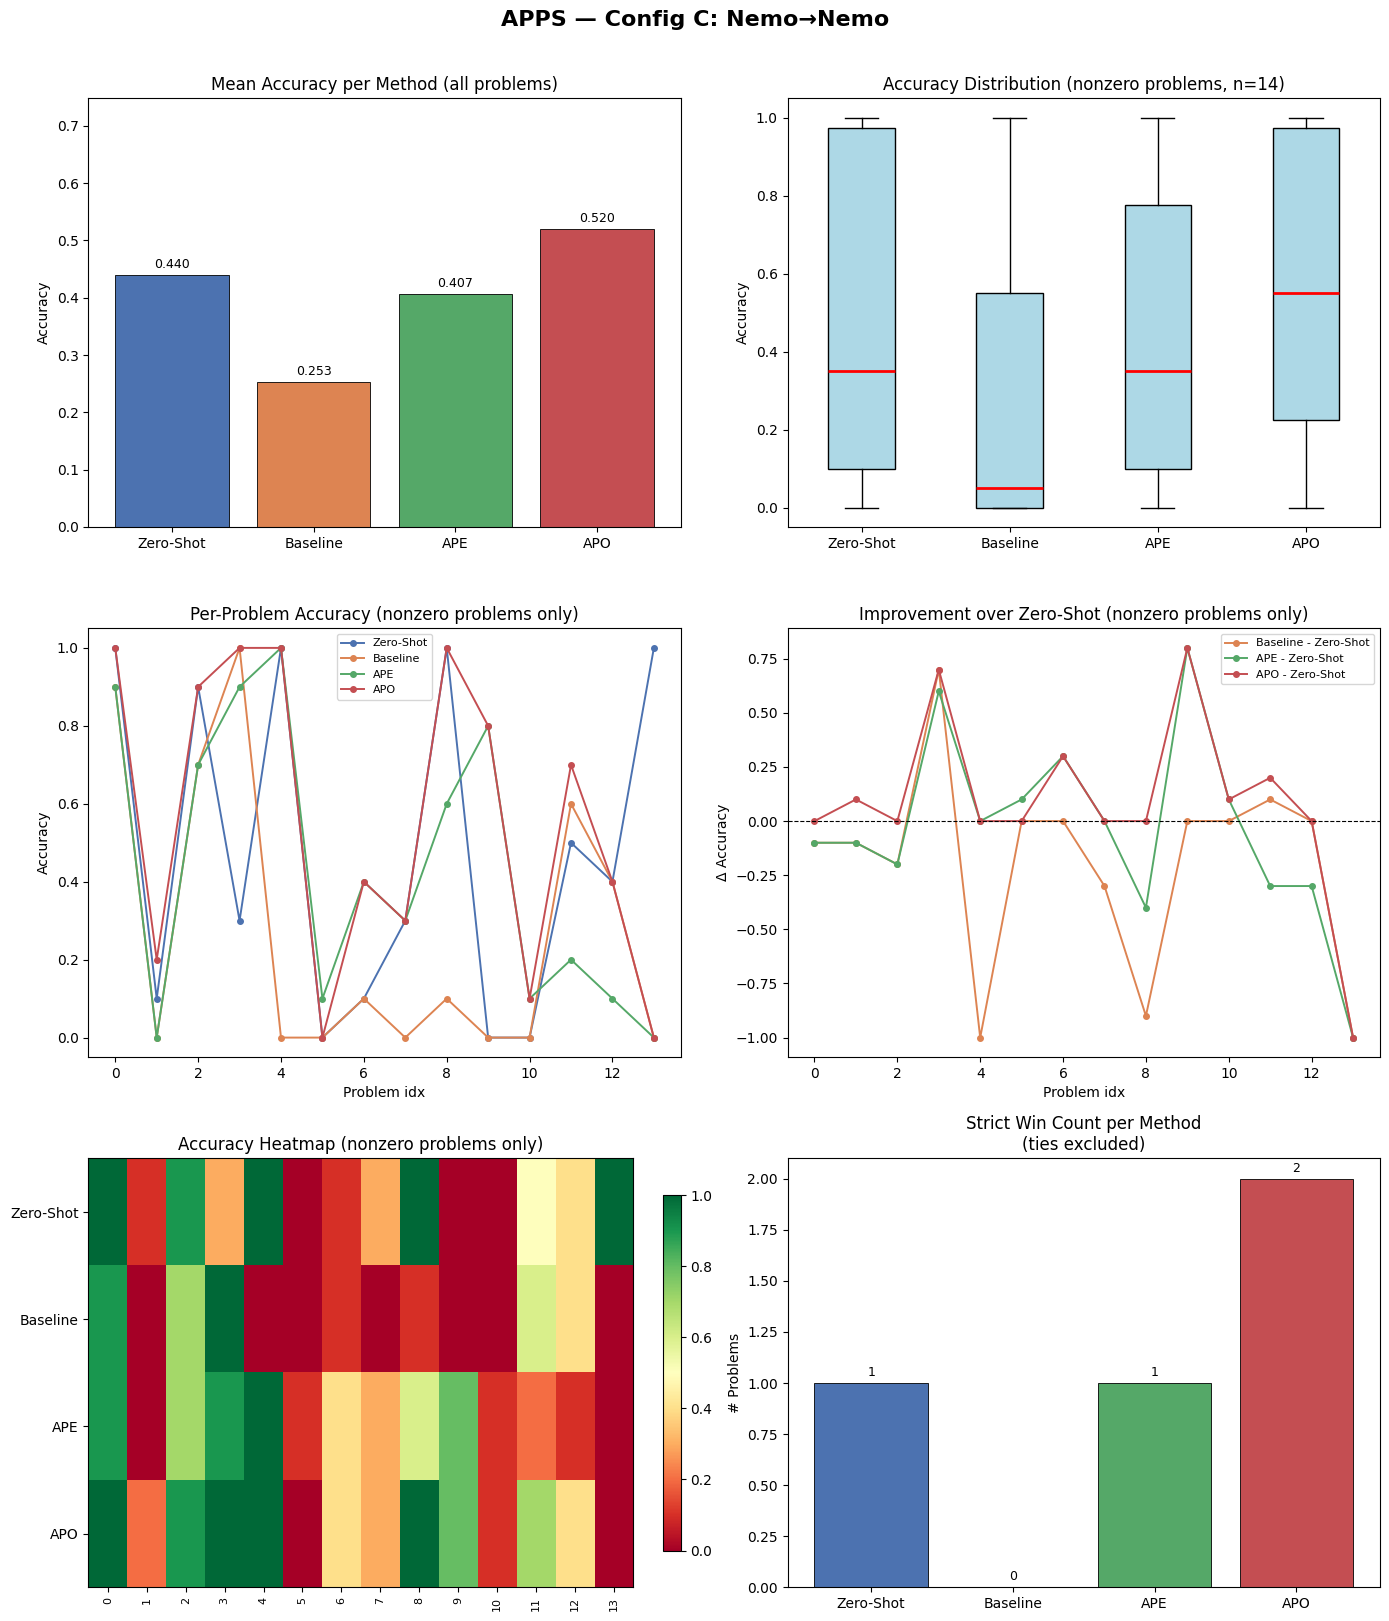

In [17]:
# Per-config initial visualization — APPS
for lbl, df in apps_dfs.items():
    short = lbl.split(':')[0]
    generate_graph(
        df,
        f'APPS — Config {lbl}',
        save_path=os.path.join(BASE, 'outputs', f'apps_config_{short}.png'),
    )


### Visualizzazioni iniziali — HumanEval (per config)

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\heval_config_A.png


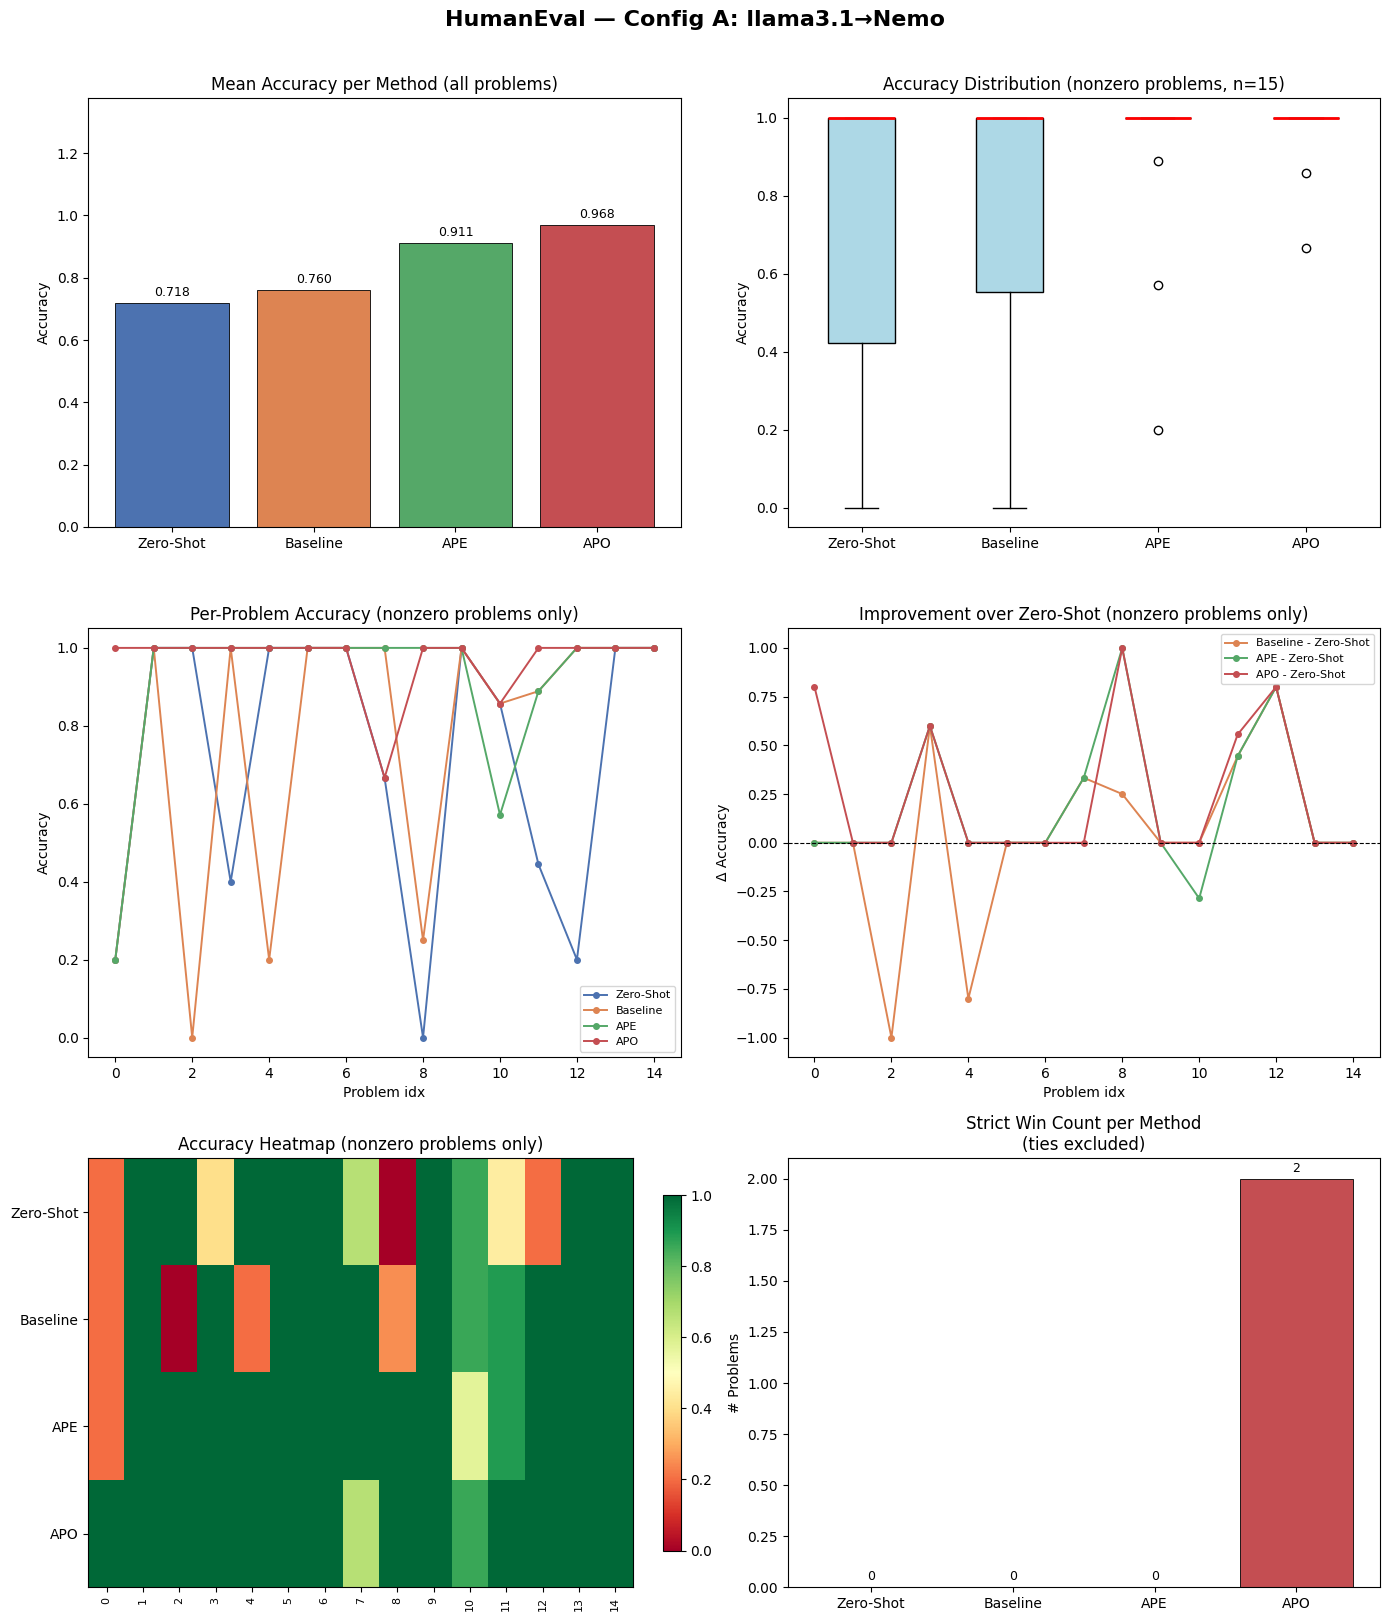

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\heval_config_B.png


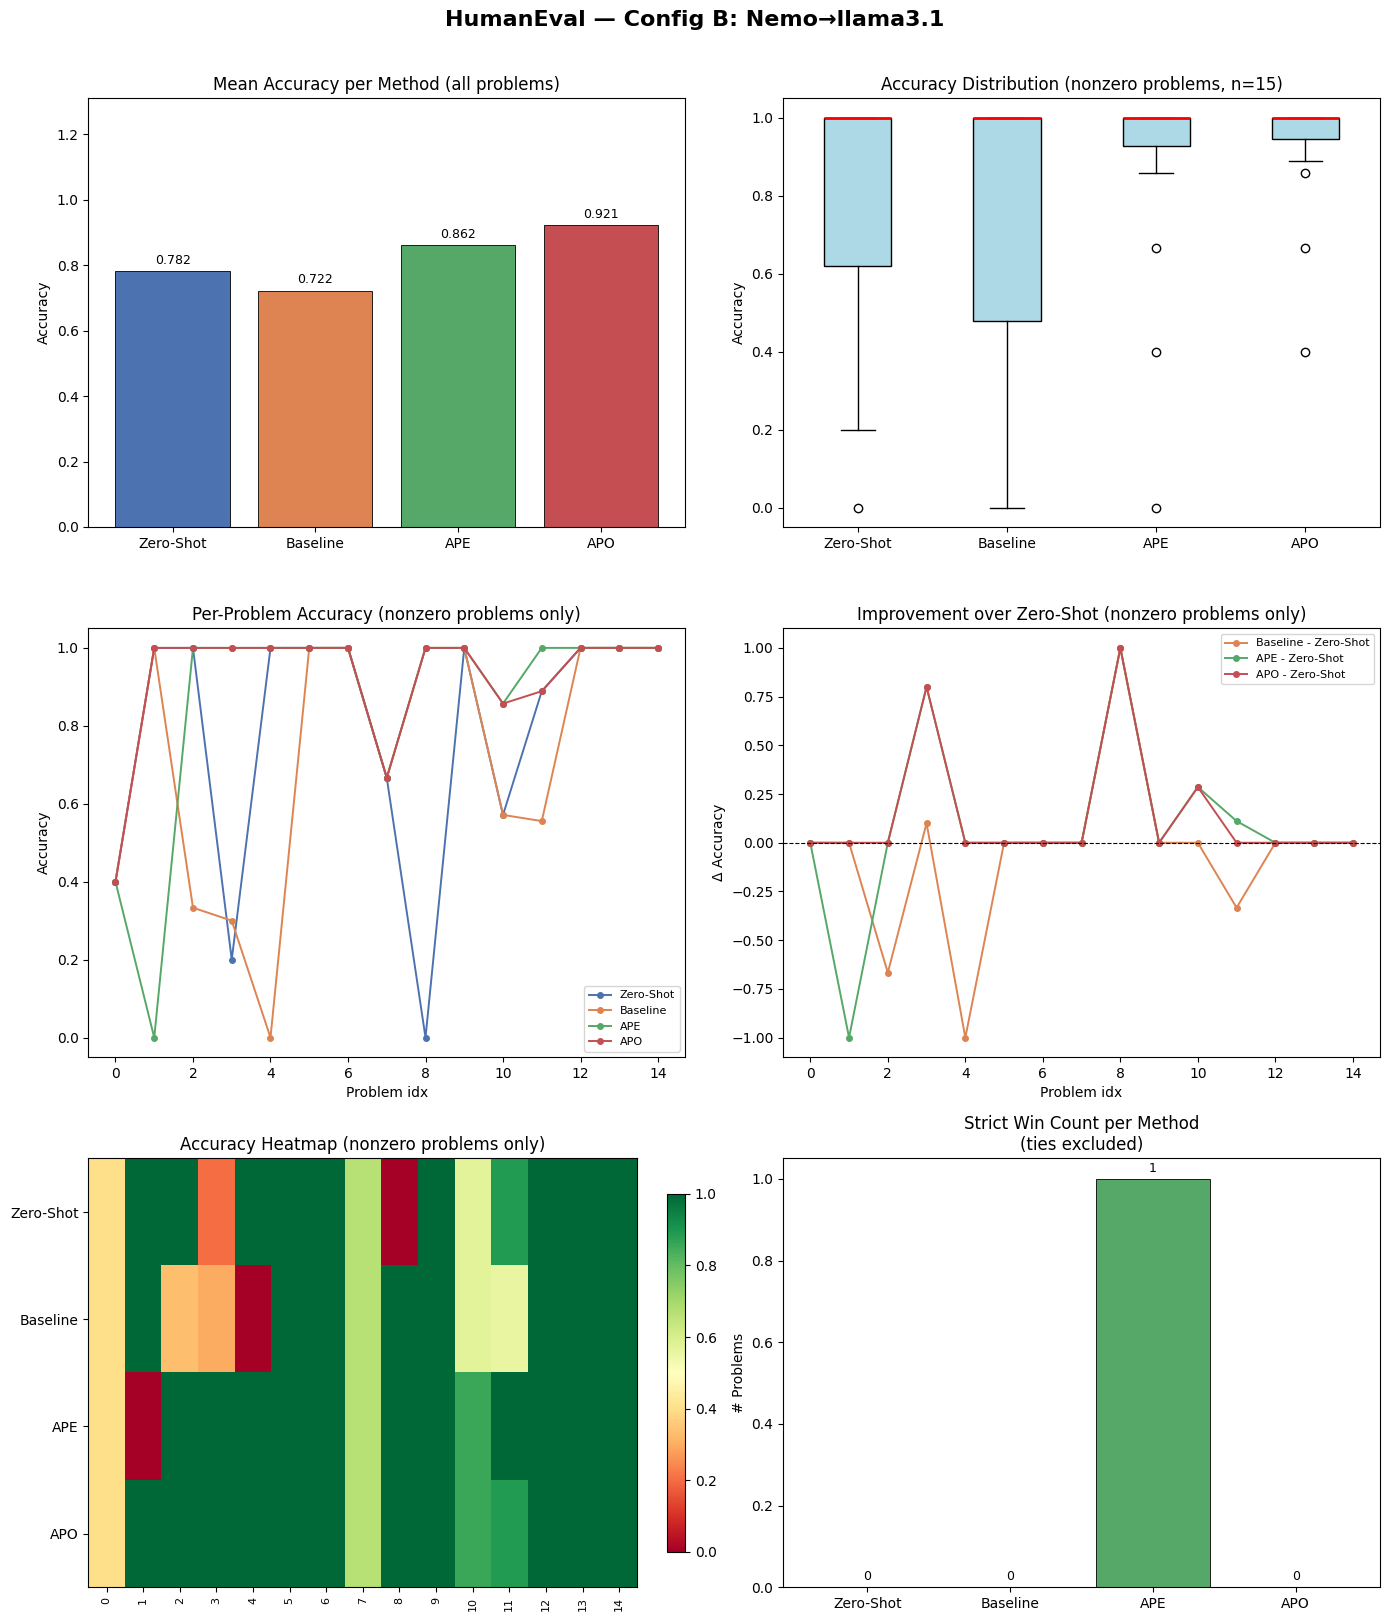

C:\Users\dernj\AppData\Local\Temp\ipykernel_34752\724861190.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_nz[m] for m in METHODS], labels=LABELS, patch_artist=True,


Saved: c:\Users\dernj\Desktop\Tesi_esperimenti\outputs\heval_config_C.png


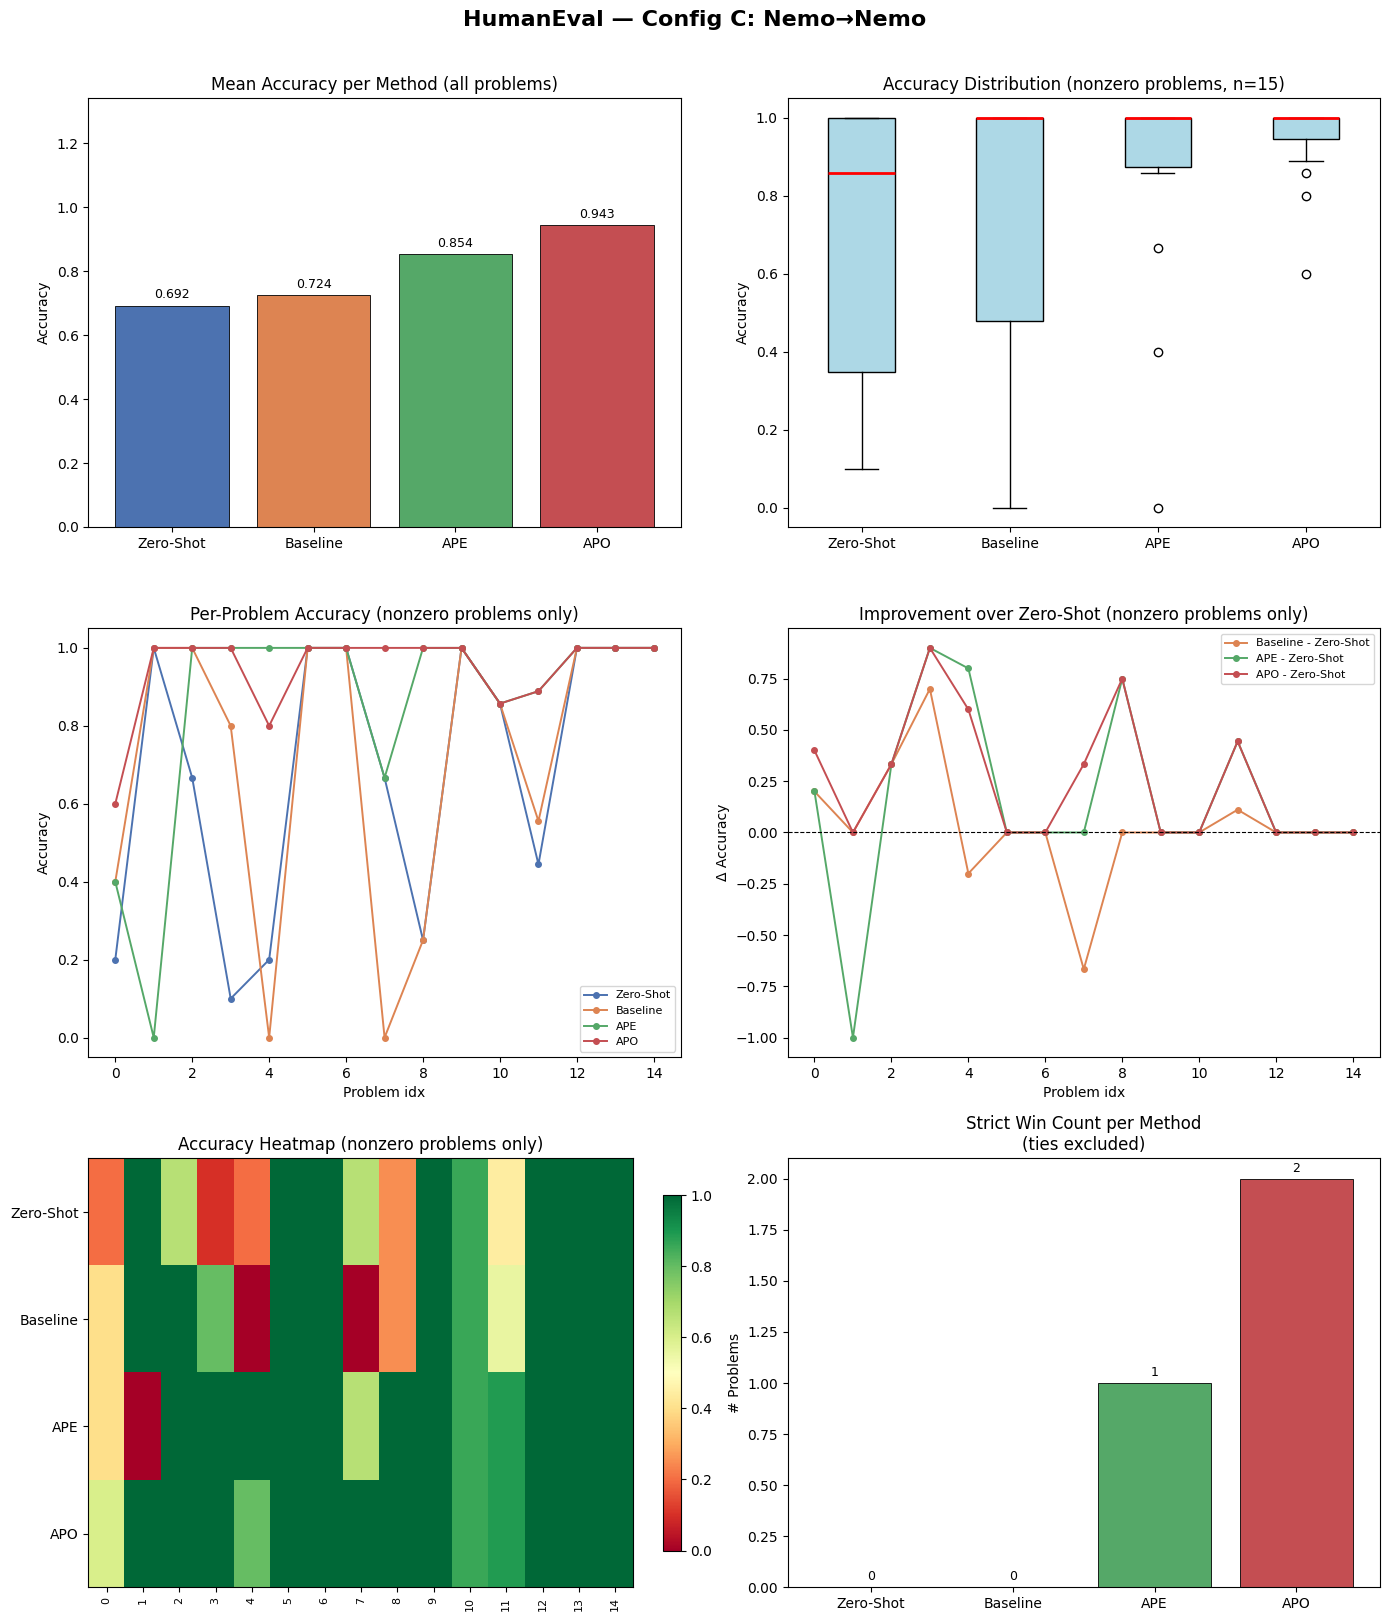

In [18]:
# Per-config initial visualization — HumanEval
for lbl, df in heval_dfs.items():
    short = lbl.split(':')[0]
    generate_graph(
        df,
        f'HumanEval — Config {lbl}',
        save_path=os.path.join(BASE, 'outputs', f'heval_config_{short}.png'),
    )


### APPS — Confronto aggregato per Difficoltà

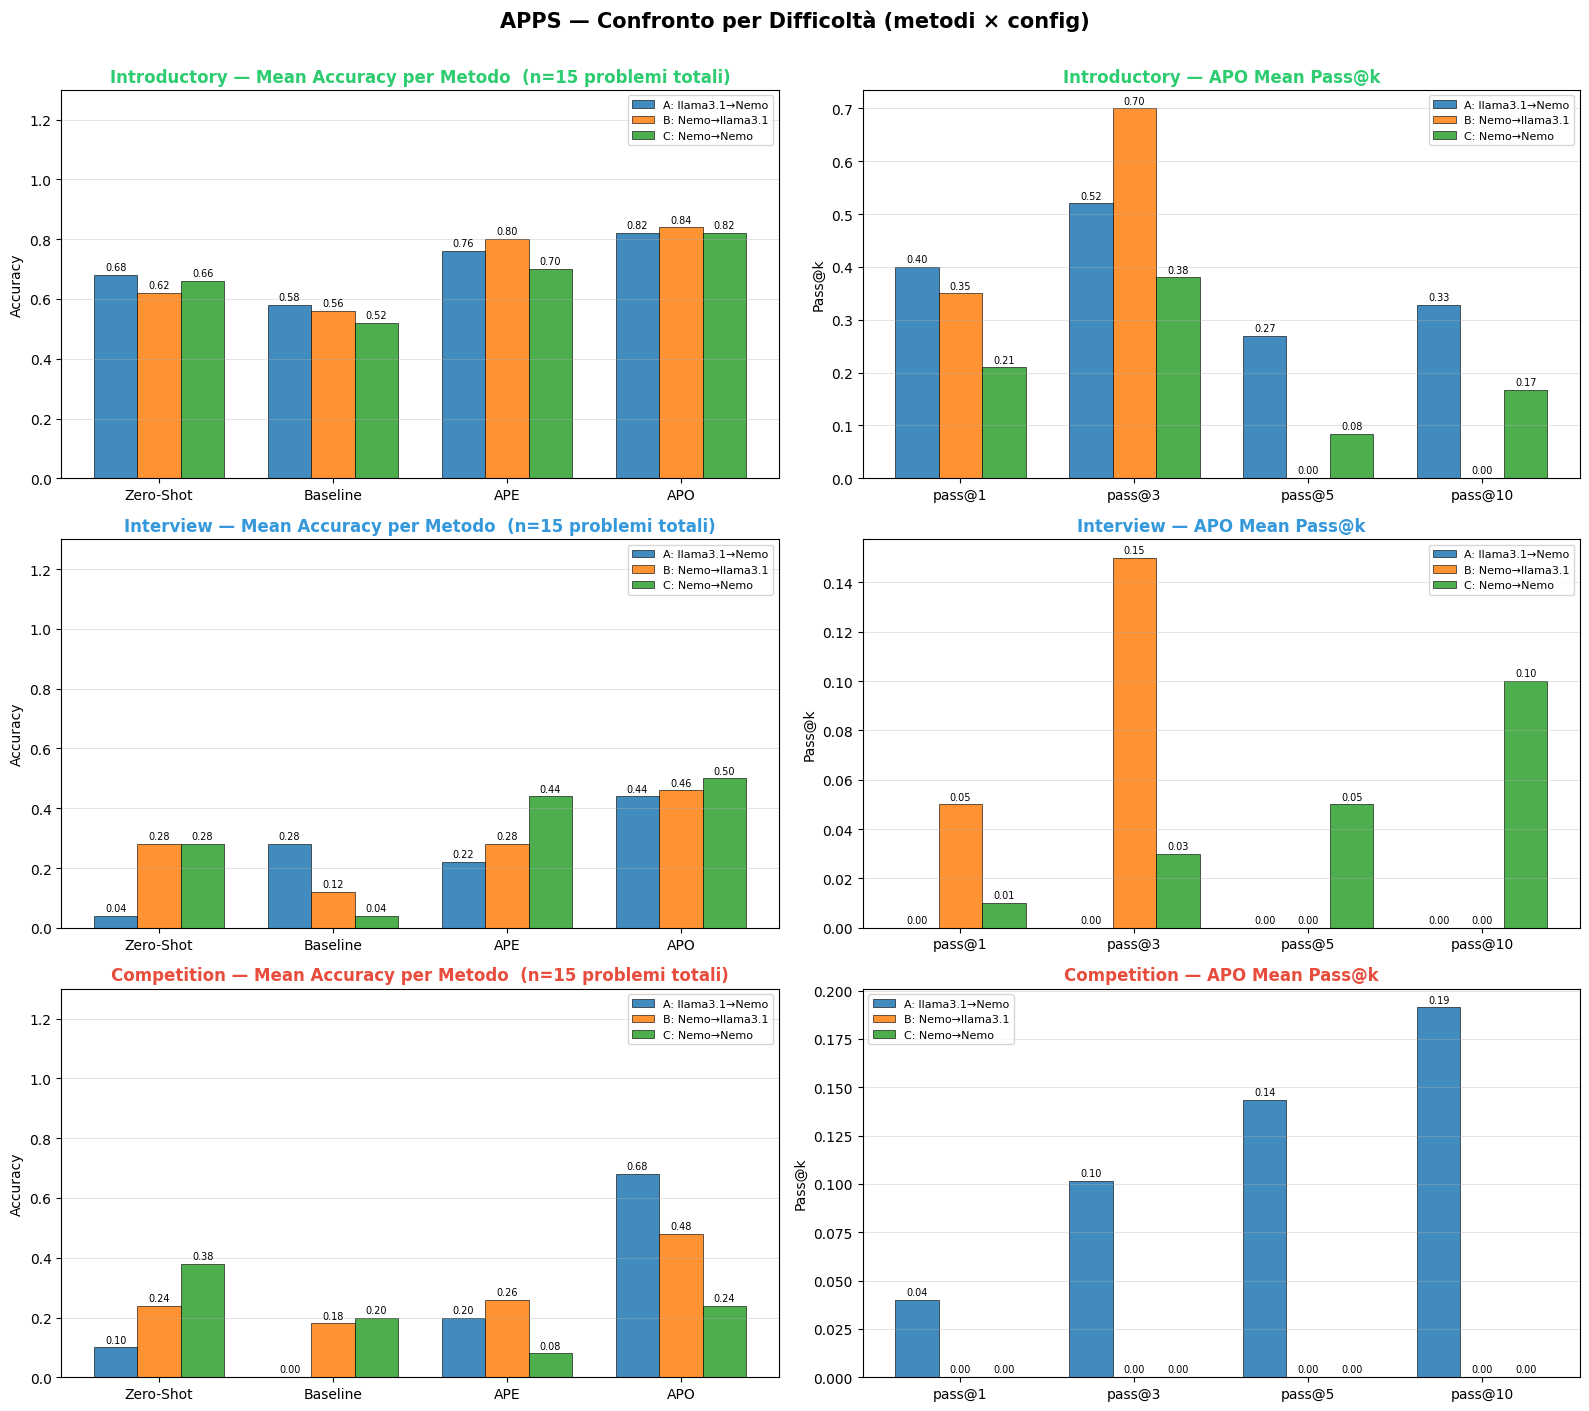

=== APPS — Mean Accuracy per Config × Difficoltà ===
                               N  Zero-Shot  Baseline   APE   APO
Config           Difficulty                                      
A: llama3.1→Nemo introductory  5       0.68      0.58  0.76  0.82
                 interview     5       0.04      0.28  0.22  0.44
                 competition   5       0.10      0.00  0.20  0.68
B: Nemo→llama3.1 introductory  5       0.62      0.56  0.80  0.84
                 interview     5       0.28      0.12  0.28  0.46
                 competition   5       0.24      0.18  0.26  0.48
C: Nemo→Nemo     introductory  5       0.66      0.52  0.70  0.82
                 interview     5       0.28      0.04  0.44  0.50
                 competition   5       0.38      0.20  0.08  0.24


N  Zero-Shot  Baseline   APE   APO
Config           Difficulty                                      
A: llama3.1→Nemo introductory  5       0.68      0.58  0.76  0.82
                 interview     5       0.04      0.28  0.22  0.44
                 competition   5       0.10      0.00  0.20  0.68
B: Nemo→llama3.1 introductory  5       0.62      0.56  0.80  0.84
                 interview     5       0.28      0.12  0.28  0.46
                 competition   5       0.24      0.18  0.26  0.48
C: Nemo→Nemo     introductory  5       0.66      0.52  0.70  0.82
                 interview     5       0.28      0.04  0.44  0.50
                 competition   5       0.38      0.20  0.08  0.24

In [19]:
# APPS: confronto metodi × config, stratificato per fascia di difficoltà
diffs         = ['introductory', 'interview', 'competition']
diff_palette  = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(len(diffs), 2, figsize=(16, 14))
fig.suptitle('APPS — Confronto per Difficoltà (metodi × config)',
             fontsize=15, fontweight='bold', y=1.005)

# Max accuracy osservata per fissare la scala y di sinistra in modo coerente
y_max_acc = max(
    (apps_dfs[lbl][apps_dfs[lbl]['difficulty'] == d][METHODS].max().max()
     for lbl, _, _ in APPS_CONFIGS for d in diffs),
    default=1.0,
)
y_max_acc = max(y_max_acc * 1.25 + 0.05, 0.2)

for row_idx, (diff, dc) in enumerate(zip(diffs, diff_palette)):
    # --- Left: grouped bar (methods × configs) for this difficulty ---
    ax = axes[row_idx, 0]
    x = np.arange(len(LABELS))
    w = 0.25
    for i, (lbl, _, color) in enumerate(APPS_CONFIGS):
        sub   = apps_dfs[lbl][apps_dfs[lbl]['difficulty'] == diff]
        means = [sub[m].mean() if len(sub) else 0 for m in METHODS]
        bars  = ax.bar(x + (i - 1) * w, means, w, label=lbl, color=color,
                       edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    n_total = sum(len(apps_dfs[lbl][apps_dfs[lbl]['difficulty'] == diff]) for lbl, _, _ in APPS_CONFIGS)
    ax.set_title(f'{diff.capitalize()} — Mean Accuracy per Metodo  (n={n_total} problemi totali)',
                 color=dc, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, y_max_acc)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.6)

    # --- Right: APO pass@k grouped by config for this difficulty ---
    ax = axes[row_idx, 1]
    x2 = np.arange(len(PASS_K_VALUES))
    for i, (lbl, _, color) in enumerate(APPS_CONFIGS):
        sub   = apps_dfs[lbl][apps_dfs[lbl]['difficulty'] == diff]
        means = [sub[f'APO_pass@{k}'].mean(skipna=True) if len(sub) else 0 for k in PASS_K_VALUES]
        bars  = ax.bar(x2 + (i - 1) * w, means, w, label=lbl, color=color,
                       edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7)
    ax.set_xticks(x2)
    ax.set_xticklabels([f'pass@{k}' for k in PASS_K_VALUES])
    ax.set_title(f'{diff.capitalize()} — APO Mean Pass@k', color=dc, fontweight='bold')
    ax.set_ylabel('Pass@k')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'apps_by_difficulty.png'),
            bbox_inches='tight', dpi=150)
plt.show()

# Tabella riassuntiva: media per metodo × difficoltà × config
rows = []
for lbl, _, _ in APPS_CONFIGS:
    df = apps_dfs[lbl]
    for diff in diffs:
        sub = df[df['difficulty'] == diff]
        rows.append({
            'Config':     lbl,
            'Difficulty': diff,
            'N':          len(sub),
            **{L: sub[m].mean() for m, L in zip(METHODS, LABELS)},
        })
apps_diff_summary = (
    pd.DataFrame(rows)
      .set_index(['Config', 'Difficulty'])
      .round(3)
)
print('=== APPS — Mean Accuracy per Config × Difficoltà ===')
print(apps_diff_summary.to_string())
apps_diff_summary


### APPS — Confronto aggregato (senza difficoltà)

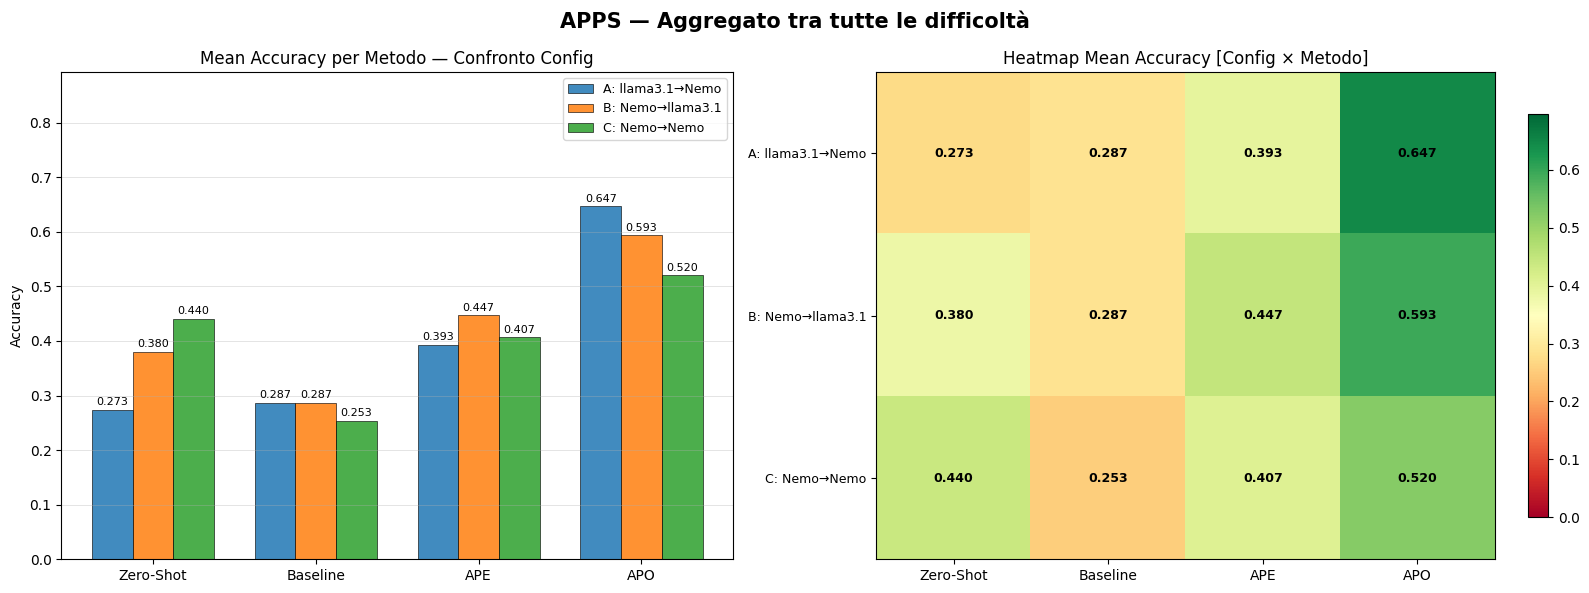

=== APPS — Mean Accuracy per Config (overall) ===
                  Zero-Shot  Baseline     APE     APO
A: llama3.1→Nemo     0.2733    0.2867  0.3933  0.6467
B: Nemo→llama3.1     0.3800    0.2867  0.4467  0.5933
C: Nemo→Nemo         0.4400    0.2533  0.4067  0.5200


,Zero-Shot,Baseline,APE,APO
A: llama3.1→Nemo,0.2733,0.2867,0.3933,0.6467
B: Nemo→llama3.1,0.3800,0.2867,0.4467,0.5933
C: Nemo→Nemo,0.4400,0.2533,0.4067,0.5200


In [20]:
# APPS: aggregato globale, senza stratificare per difficoltà
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('APPS — Aggregato tra tutte le difficoltà', fontsize=15, fontweight='bold')

# --- Left: grouped bar methods × configs ---
ax = axes[0]
x = np.arange(len(LABELS))
w = 0.25
for i, (lbl, _, color) in enumerate(APPS_CONFIGS):
    means = [apps_dfs[lbl][m].mean() for m in METHODS]
    bars  = ax.bar(x + (i - 1) * w, means, w, label=lbl, color=color,
                   edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_title('Mean Accuracy per Metodo — Confronto Config')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=9)
ax.grid(axis='y', linewidth=0.4, alpha=0.6)
max_val = max(apps_dfs[lbl][m].mean() for lbl, _, _ in APPS_CONFIGS for m in METHODS)
ax.set_ylim(0, max(max_val * 1.35 + 0.02, 0.1))

# --- Right: heatmap [config × method] ---
ax = axes[1]
cfg_names = [lbl for lbl, _, _ in APPS_CONFIGS]
heat = np.array([[apps_dfs[lbl][m].mean() for m in METHODS] for lbl in cfg_names])
im = ax.imshow(heat, cmap='RdYlGn', vmin=0, vmax=max(heat.max() + 0.05, 0.1), aspect='auto')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(cfg_names))); ax.set_yticklabels(cfg_names, fontsize=9)
for i in range(len(cfg_names)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{heat[i, j]:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold')
ax.set_title('Heatmap Mean Accuracy [Config × Metodo]')
plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'apps_overall.png'),
            bbox_inches='tight', dpi=150)
plt.show()

apps_overall_summary = pd.DataFrame(
    {L: [apps_dfs[lbl][m].mean() for lbl, _, _ in APPS_CONFIGS]
     for m, L in zip(METHODS, LABELS)},
    index=[lbl for lbl, _, _ in APPS_CONFIGS],
).round(4)
print('=== APPS — Mean Accuracy per Config (overall) ===')
print(apps_overall_summary.to_string())
apps_overall_summary


### HumanEval — Confronto aggregato (non ci sono difficoltà)

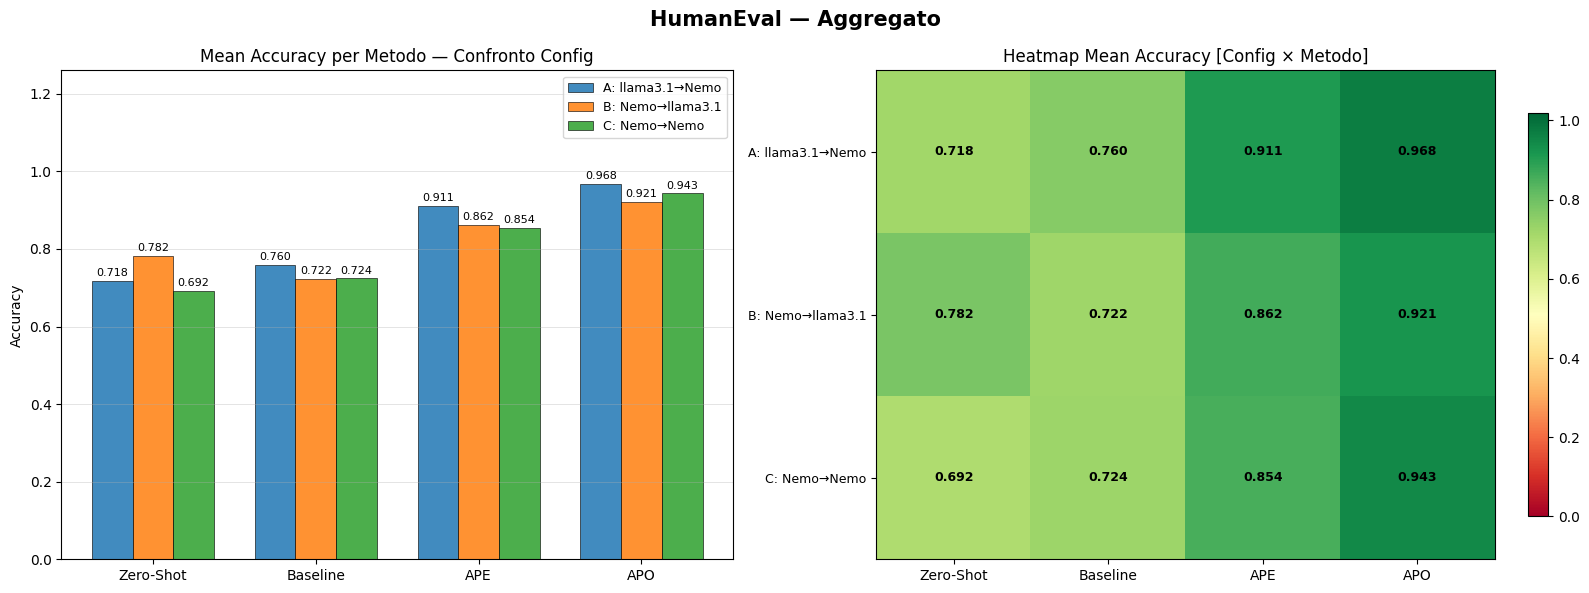

=== HumanEval — Mean Accuracy per Config ===
                  Zero-Shot  Baseline     APE     APO
A: llama3.1→Nemo     0.7179    0.7597  0.9107  0.9683
B: Nemo→llama3.1     0.7818    0.7218  0.8616  0.9208
C: Nemo→Nemo         0.6923    0.7242  0.8542  0.9431


,Zero-Shot,Baseline,APE,APO
A: llama3.1→Nemo,0.7179,0.7597,0.9107,0.9683
B: Nemo→llama3.1,0.7818,0.7218,0.8616,0.9208
C: Nemo→Nemo,0.6923,0.7242,0.8542,0.9431


In [21]:
# HumanEval: aggregato (senza fasce di difficoltà)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HumanEval — Aggregato', fontsize=15, fontweight='bold')

# --- Left: grouped bar methods × configs ---
ax = axes[0]
x = np.arange(len(LABELS))
w = 0.25
for i, (lbl, _, color) in enumerate(HEVAL_CONFIGS):
    means = [heval_dfs[lbl][m].mean() for m in METHODS]
    bars  = ax.bar(x + (i - 1) * w, means, w, label=lbl, color=color,
                   edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_title('Mean Accuracy per Metodo — Confronto Config')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=9)
ax.grid(axis='y', linewidth=0.4, alpha=0.6)
max_val = max(heval_dfs[lbl][m].mean() for lbl, _, _ in HEVAL_CONFIGS for m in METHODS)
ax.set_ylim(0, max(max_val * 1.25 + 0.05, 0.2))

# --- Right: heatmap [config × method] ---
ax = axes[1]
cfg_names = [lbl for lbl, _, _ in HEVAL_CONFIGS]
heat = np.array([[heval_dfs[lbl][m].mean() for m in METHODS] for lbl in cfg_names])
im = ax.imshow(heat, cmap='RdYlGn', vmin=0, vmax=max(heat.max() + 0.05, 0.1), aspect='auto')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(cfg_names))); ax.set_yticklabels(cfg_names, fontsize=9)
for i in range(len(cfg_names)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{heat[i, j]:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold')
ax.set_title('Heatmap Mean Accuracy [Config × Metodo]')
plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'heval_overall.png'),
            bbox_inches='tight', dpi=150)
plt.show()

heval_overall_summary = pd.DataFrame(
    {L: [heval_dfs[lbl][m].mean() for lbl, _, _ in HEVAL_CONFIGS]
     for m, L in zip(METHODS, LABELS)},
    index=[lbl for lbl, _, _ in HEVAL_CONFIGS],
).round(4)
print('=== HumanEval — Mean Accuracy per Config ===')
print(heval_overall_summary.to_string())
heval_overall_summary
